# Libraries

In [7]:
from _utils import *

In [8]:
# Set up credentials and connect to Google Sheets
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("gsheet-creds.json", scope)
client = gspread.authorize(creds)

# Functions

In [9]:
def plot_countplot(
    df,
    col,
    subset_query=None,
    title=None,
    color='#4C72B0',
    horizontal=True,
    figsize=(8, 5),
    show_counts=False
):
    """
    Create a countplot from a column in a pandas DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        Your input DataFrame.
    col : str
        Column to count and plot.
    subset_query : str, optional
        Optional query string to filter the DataFrame (e.g., "type == 'Neither'").
    title : str, optional
        Title for the plot.
    color : str, optional
        Bar color (default: '#4C72B0').
    horizontal : bool, default True
        If True, plot bars horizontally.
    figsize : tuple, optional
        Figure size in inches.
    show_counts : bool, default False
        If True, annotate bars with counts.
    """
    data = df.query(subset_query) if subset_query else df
    order = data[col].value_counts().index

    plt.figure(figsize=figsize)
    ax = sns.countplot(
        data=data,
        y=col if horizontal else None,
        x=None if horizontal else col,
        order=order,
        color=color
    )

    if show_counts:
        for p in ax.patches:
            count = int(p.get_width() if horizontal else p.get_height())
            pos_x = p.get_width() + 0.5 if horizontal else p.get_x() + p.get_width() / 2
            pos_y = p.get_y() + p.get_height() / 2 if horizontal else p.get_height() + 0.5
            if horizontal:
                ax.text(count + 0.5, p.get_y() + p.get_height()/2, str(count), va='center')
            else:
                ax.text(p.get_x() + p.get_width()/2, count + 0.5, str(count), ha='center')

    ax.set_title(title or f"Count of {col}")
    ax.set_xlabel("Count" if horizontal else col)
    ax.set_ylabel(col if horizontal else "Count")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

def View(df, rows=None, cols=None, width=None):
    """Displays the first `rows` of the DataFrame like R's View() by adjusting Pandas settings."""
    
    # Show only the first `rows` of the DataFrame
    with pd.option_context(
        "display.max_rows", rows,  # Limit number of rows shown
        "display.max_columns", cols,  # Show all columns
        "display.max_colwidth", width,  # Show full column width
        "display.expand_frame_repr", False  # Prevent column wrapping
    ):
        display(df.head(rows))  # Show only the first `rows`

# Function to extract mod directory from the URL
def get_dir(url):
    match = re.search(r"file=([^/]+)/[^/]+\.mod", url)  # Extract the directory name before the .mod file
    return match.group(1) if match else None  # Return directory name if found, else None

# Function to extract mod file name without extension
def get_fname(url):
    match = re.search(r"/([^/]+)\.mod$", url)  # Get filename without extension
    return match.group(1) if match else None  # Return only the name (e.g., 'na')

# Function to extract model_id from the URL
def get_model_id(url):
    match = re.search(r"https://modeldb\.science/(\d+)", url)
    return int(match.group(1)) if match else None  # Convert to integer

# Function to extract all TITLE occurrences from .mod content
def get_title(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"^TITLE\s+([^\n:]+)", content, re.MULTILINE)  # Stop at comments
    return matches if matches else None

# Function to extract all COMMENT sections from .mod content
def get_comment(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"COMMENT\s+(.*?)(?:\s+ENDCOMMENT|\Z)", content, re.DOTALL)  
    return matches if matches else None

# Function to extract all SUFFIX occurrences from .mod content
def get_suffix(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"SUFFIX\s+([^\n:\s]+)", content, re.MULTILINE)  # Stop at comments
    return matches if matches else None


def get_use_ion(content):
    """
    Extracts the ion names used in the 'USEION' statements from NEURON mod file content.

    Parameters:
    - content (str): The content of the .mod file.

    Returns:
    - list: A list of ions used in 'USEION' statements, or None if none are found.
    """
    if pd.isna(content):  
        return None
    
    # Find all occurrences of USEION followed by an ion name
    matches = re.findall(r"USEION\s+(\w+)", content, re.MULTILINE)

    return matches if matches else None


# Function to extract all ions listed after READ but stopping before WRITE, USEION, RANGE, GLOBAL, NONSPECIFIC_CURRENT, or VALENCE
def get_read_ion(content):
    if pd.isna(content):  
        return None
    
    matches = re.findall(r"USEION\s+\w+\s+READ\s+([\w,\s]+?)(?=\s+(?:WRITE|USEION|RANGE|GLOBAL|NONSPECIFIC_CURRENT|VALENCE|:|\n|$))", content, re.MULTILINE)

    if not matches:
        return None

    read_ions = [ion.strip() for match in matches for ion in re.split(r"[,\s]+", match) if ion]

    return read_ions if read_ions else None  


# Function to extract all ions listed after WRITE, stopping before VALENCE
def get_write_ion(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"WRITE\s+([^\n:]+?)(?=\s+(?:VALENCE|:|\n|$))", content, re.MULTILINE)

    if not matches:
        return None

    write_ions = [ion.strip() for match in matches for ion in re.split(r"[,\s]+", match) if ion]

    return write_ions if write_ions else None  


def write_current_yn(ions):
    """
    Checks if mod_write_ion contains an ion that starts with 'i' (indicating a current).

    Args:
        write_ions (list): List of ions written in the mod file.

    Returns:
        int: 1 if any ion starts with 'i', otherwise 0.
    """
    if not ions:  # Handle empty lists or None
        return 0

    return int(any(ion.startswith("i") for ion in ions))


# Function to extract all NONSPECIFIC currents
def get_nonspecific_current(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"NONSPECIFIC_CURRENT\s+([^\n:]*)", content)

    if not matches:
        return None

    nonspecific_currents = [curr.strip() for match in matches for curr in re.split(r"[,\s]+", match) if curr]

    return nonspecific_currents if nonspecific_currents else None  

#todo: should we assume we only want active variables or also extract ones that are commented out?
# Function to extract RANGE variables based on mode
def get_range(content, mode="active"):
    if pd.isna(content):
        return None  # Return None if content is missing

    # Extract active RANGE variables (not commented out)
    active_matches = re.findall(r"^\s*RANGE\s+([\w\s,]+)", content, re.MULTILINE)

    # Extract commented-out RANGE variables (lines starting with ": RANGE")
    commented_matches = re.findall(r"^\s*:\s*RANGE\s+([\w\s,]+)", content, re.MULTILINE)

    # Process active RANGE variables
    active_vars = [var.strip() for match in active_matches for var in re.split(r"[,\s]+", match) if var]

    # Process commented-out RANGE variables
    commented_vars = [var.strip() for match in commented_matches for var in re.split(r"[,\s]+", match) if var]

    if mode == "active":
        return active_vars if active_vars else None
    elif mode == "commented":
        return commented_vars if commented_vars else None
    elif mode == "all":
        return {"active": active_vars if active_vars else None, "commented": commented_vars if commented_vars else None}
    else:
        raise ValueError("Invalid mode! Choose from 'all', 'active', or 'commented'.")


# Function to extract only active RANGE variables, stopping at colons and the end of the line
def get_range(content):
    if pd.isna(content):
        return None  # Return None if content is missing

    # Extract all RANGE statements (each line separately), stopping before colons
    matches = re.findall(r"^\s*RANGE\s+([^\n:]*)", content, re.MULTILINE)

    if not matches:
        return None

    # Process active RANGE variables, ensuring they don't capture anything past the colon
    active_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return active_vars if active_vars else None  # Return only active variables
    
# Function to extract parameter names and values as a dictionary
def get_parameter(content):
    if pd.isna(content):  
        return None
    
    matches = re.findall(r"PARAMETER\s*\{([^}]*)\}", content, re.MULTILINE)

    if not matches:
        return None

    param_dict = {}
    
    for match in matches:
        for line in match.split("\n"):
            line = line.strip()
            if line.startswith(":"):  # Ignore commented-out lines
                continue
            param_match = re.match(r"(\w+)\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", line)
            if param_match:
                param_name, param_value = param_match.groups()
                param_dict[param_name] = float(param_value)  

    return param_dict if param_dict else None  

# Function to extract only active STATE variables, ignoring comments (`:`) and unit values `(mV)`, etc.
def get_state(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"STATE\s*\{([^}]*)\}", content, re.MULTILINE)

    if not matches:
        return None

    state_vars = []
    for match in matches:
        for line in match.split("\n"):
            line = line.strip()
            if line.startswith(":"):  # Ignore fully commented-out lines
                continue
            line = re.split(r"\s*:\s*", line)[0]  # Remove inline comments (anything after `:`)
            clean_line = re.sub(r"\([^)]*\)", "", line).strip()  # Remove unit values
            if clean_line:
                state_vars.append(clean_line)

    return state_vars if state_vars else None  



# New function
def get_derivative(content):
    """
    If a DERIVATIVE block exists, return the number of derivative assignments (e.g., m' = ...).
    Otherwise, return the STATE variables (same behavior as get_state).
    """
    if pd.isna(content):
        return None

    text = str(content)

    # Grab all DERIVATIVE blocks (name is optional: e.g., "DERIVATIVE states { ... }")
    blocks = re.findall(r"DERIVATIVE\b[^\{]*\{([^}]*)\}", text, flags=re.IGNORECASE | re.DOTALL)

    if not blocks:
        # No derivative block → behave like get_state
        return get_state(content)

    def _strip_comments(s: str) -> str:
        cleaned = []
        for line in s.splitlines():
            line = line.strip()
            if line.startswith(":"):
                continue  # drop full-line comments
            # remove inline comments after first colon
            line = line.split(":", 1)[0].strip()
            if line:
                cleaned.append(line)
        return "\n".join(cleaned)

    # Count assignments of the form "<ident>' ="
    derivative_count = 0
    for blk in blocks:
        cleaned = _strip_comments(blk)
        assignments = re.findall(r"\b([A-Za-z_]\w*)'\s*=", cleaned)
        derivative_count += len(assignments)

    return derivative_count



# Function to extract only active GLOBAL variables, ignoring commented-out (`:`) ones
def get_global(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"^\s*GLOBAL\s+([^\n:]*)", content, re.MULTILINE)

    if not matches:
        return None

    global_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return global_vars if global_vars else None  


def get_net_receive(content):
    """
    Extracts all NET_RECEIVE block arguments from MOD file content.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        list or None: A list of extracted NET_RECEIVE arguments, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Find all occurrences of NET_RECEIVE and extract arguments
    matches = re.findall(r"^\s*NET_RECEIVE\s*\(\s*([\w, ]+)\s*\)", content, re.MULTILINE)

    if not matches:
        return None

    net_receive_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return net_receive_vars if net_receive_vars else None

#todo: modify pipeline so that if get_include points to a file that file will be included in the content too
def get_include(content):
    """
    Extracts the filename in the INCLUDE statement from MOD file content, ignoring comments.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        list or None: A list of extracted INCLUDE filenames, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Find all occurrences of INCLUDE, ensuring commented-out ones (with ':') are ignored
    matches = re.findall(r"^\s*INCLUDE\s+\"([^\"]+)\"", content, re.MULTILINE)

    return matches if matches else None


def get_point_process(content):
    """
    Extracts the POINT_PROCESS name from MOD file content.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        str or None: The extracted POINT_PROCESS name, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Extract the POINT_PROCESS name, ignoring comments
    match = re.search(r"^\s*POINT_PROCESS\s+([^\n:]+)", content, re.MULTILINE)

    return match.group(1).strip() if match else None


    
# Function to extract webpage heading
def get_heading(url):
    try:
        response = requests.get(url, timeout=10)  # Fetch the webpage
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")
        
        # Try extracting heading from the most relevant tag
        heading = soup.find("h1")  # Look for <h1> (main title)
        return heading.text.strip() if heading else None  # Return text or None
    except requests.exceptions.RequestException:
        return None  # Return None if the request fail

# Function to extract citation (text inside parentheses)
def get_citation(heading):
    if pd.isna(heading):
        return None
    match = re.search(r"\(([^)]+)\)", heading)  # Find text inside parentheses
    return match.group(1) if match else None  # Extract citation


# Function to extract first author(s) (removes "et al." and "al" correctly)
def get_author(citation):
    if pd.isna(citation):
        return None

    # Extract first author(s) before "et al" or variants
    match = re.search(r"^([\w\s&\-,]+?)(?:\s+et\s+al\.?|et)?(?:,|\s|$)", citation)  
    first_author = match.group(1).strip() if match else None  

    # Remove any trailing "al" left behind
    if first_author:
        first_author = re.sub(r"\b(al)\b", "", first_author, flags=re.IGNORECASE).strip()

    return first_author

# Function to extract the first year from citation (including shortened years like '20)
def get_year(citation):
    if pd.isna(citation):
        return None
    match = re.search(r"\b(19|20)?\d{2}\b|'\d{2}", citation)  # Find 4-digit or short year ('20)
    if match:
        return match.group(0).replace("'", "")  # Remove apostrophe but keep year as '20' if short
    return None  # Return None if no year found






def has_electrode_or_clamp(mod_name, content):
    """
    Checks whether 'clamp' is present in the mod file name OR 
    'ELECTRODE_CURRENT' is present in the NEURON mod file content.

    Parameters:
    - mod_name (str): The name of the .mod file.
    - content (str): The content of the .mod file.

    Returns:
    - int: 1 if either 'clamp' is in the mod name OR 'ELECTRODE_CURRENT' is in the content, 0 otherwise.
    """
    if pd.isna(mod_name) and pd.isna(content):
        return None  # Return None if both are missing

    has_clamp = bool(re.search(r"clamp", str(mod_name), re.IGNORECASE)) if pd.notna(mod_name) else False
    has_electrode = bool(re.search(r"\bELECTRODE_CURRENT\b", str(content))) if pd.notna(content) else False

    return 1 if has_clamp or has_electrode else 0

def map_ion(value):
    value = value.lower()  # Normalize to lowercase

    # Define regex-based categorization rules
    patterns = [
        (r'ca.*i$', 'ca_i'),
        (r'ca.*o$', 'ca_o'),
        (r'cl.*i$', 'cl_i'),
        (r'cl.*o$', 'cl_o'),
        (r'k.*i$', 'k_i'),
        (r'k.*o$', 'k_o'),
        (r'na.*i$', 'na_i'),
        (r'na.*o$', 'na_o'),
        (r'hco3.*i$', 'other_i'),
        (r'hco3.*o$', 'other_o'),
        (r'mgi$', 'mg_i'),  
        (r'mgo$', 'mg_o'),  
        (r'^img$', 'i_mg'),  
        (r'^emg$', 'e_mg'),
        (r'^e.*ca', 'e_ca'),
        (r'^e.*k', 'e_k'),
        (r'^e.*na', 'e_na'),
        (r'^e.*mg', 'e_mg'),
        (r'^e.*', 'e_other'),
        (r'^i.*ca', 'i_cal'),
        (r'^i.*k', 'i_k'),
        (r'^i.*cl', 'i_cl'),
        (r'^i.*na$', 'i_na'),  # FIX: Ensure "ina" is classified as "i_na"
        (r'^i.*mg', 'i_mg'),
        (r'^i.*', 'i_other'),
        (r'.*i$', 'other_i'),  # General rule: Anything ending in "i" is "other_i"
        (r'.*o$', 'other_o')   # General rule: Anything ending in "o" is "other_o"
    ]
    # Apply the regex patterns
    for pattern, category in patterns:
        if re.search(pattern, value):
            return category

    return "unknown"  # Default category if no match is found

def count_states(df, column_name="state"):
    """Counts the number of states in each row of the specified column."""
    df["count_states"] = df[column_name].apply(lambda x: len(x) if isinstance(x, list) else 0)
    return df



def get_tau(param_dict):
    if not isinstance(param_dict, dict):
        return None, None  # Return separate None values for direct unpacking

    # Extract values where the key contains 'tau'
    tau_values = [v for k, v in param_dict.items() if 'tau' in k.lower()]
    
    # If no tau values found, return (None, None)
    if not tau_values:
        return None, None
    
    # Compute min and max
    return min(tau_values), max(tau_values)


def get_e(param_dict):
    if not isinstance(param_dict, dict):
        return [None, None]  # Handle cases where the value is not a dictionary

    #todo: modify the v pattern so it takes like 2 characters max
    # Regex pattern to match variations of reversal potential names
    pattern = re.compile(r"^(e|rev|v|shift).*", re.IGNORECASE)

    # Extract values where the key matches the pattern
    e_values = [v for k, v in param_dict.items() if pattern.match(k)]

    # If no values found, return [None, None]
    if not e_values:
        return [None, None]

    # Compute min and max reversal potential
    return min(e_values), max(e_values)



def has_mg(content):
    """
    Checks if 'mg' appears anywhere in the given content.

    Args:
        content (str): The text content to search.

    Returns:
        int: 1 if 'mg' is found, 0 otherwise.
    """
    if pd.isna(content):  # Handle missing content
        return 0

    return int(bool(re.search(r"mg", content, re.IGNORECASE)))  # Convert Boolean to int


def plot_countplot(
    df,
    col,
    subset_query=None,
    title=None,
    color='#4C72B0',
    horizontal=True,
    figsize=(8, 5),
    show_counts=False
):
    """
    Create a Seaborn countplot with options for filtering, orientation, and annotations.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input data.
    col : str
        Column to count and plot.
    subset_query : str, optional
        Pandas query string to filter data before plotting (e.g., "type == 'Neither'").
    title : str, optional
        Title of the plot.
    color : str, optional
        Color of the bars.
    horizontal : bool, default True
        If True, plot horizontal bars; else vertical.
    figsize : tuple, default (8, 5)
        Figure size.
    show_counts : bool, default False
        If True, annotate bars with counts.
    """
    data = df.query(subset_query) if subset_query else df
    order = data[col].value_counts().index

    plt.figure(figsize=figsize)
    ax = sns.countplot(
        data=data,
        y=col if horizontal else None,
        x=None if horizontal else col,
        order=order,
        color=color
    )

    if show_counts:
        for p in ax.patches:
            count = int(p.get_width() if horizontal else p.get_height())
            if horizontal:
                ax.text(
                    p.get_width() + 0.5,
                    p.get_y() + p.get_height() / 2,
                    str(count),
                    va='center'
                )
            else:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    p.get_height() + 0.5,
                    str(count),
                    ha='center'
                )

    ax.set_title(title or f'Count of {col}')
    ax.set_xlabel('Count' if horizontal else col)
    ax.set_ylabel(col if horizontal else 'Count')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

# Highlight count < 10
def highlight_rare_rows(row):
    color = 'background-color: lightcoral' if row['count'] < 10 else ''
    return [color] * len(row)


def get_count_df(df, group_cols, sort_col=None):
    if sort_col is None:
        sort_col = group_cols[0]
    
    return (
        df
        .groupby(group_cols)
        .size()
        .reset_index(name='count')
        .assign(
            overall_pct = lambda d: (d['count'] / d['count'].sum() * 100).round(2),
            subtype_pct = lambda d: (
                d.groupby(group_cols[0])['count']
                .transform(lambda x: (x / x.sum()) * 100)
                .round(2)
            )
        )
        .sort_values([sort_col, 'count'], ascending=[True, False])
    )

def plot_partial_credit_heatmap(y_true, y_pred, similarity_matrix):
    """
    Plots a heatmap of average similarity scores between true and predicted labels.
    
    Parameters:
    - y_true: list or array of true labels (strings)
    - y_pred: list or array of predicted labels (strings)
    - similarity_matrix: pandas DataFrame with labels as index and columns, containing similarity scores
    """
    # Get all unique labels
    all_labels = sorted(set(y_true) | set(y_pred))
    
    # Build confusion-style count matrix
    confusion_counts = pd.DataFrame(0, index=all_labels, columns=all_labels)
    for true, pred in zip(y_true, y_pred):
        confusion_counts.loc[true, pred] += 1

    # Compute similarity-weighted scores
    weighted_scores = confusion_counts * similarity_matrix

    # Normalize to average similarity per true label
    normalized_similarity = weighted_scores.div(confusion_counts.sum(axis=1).replace(0, np.nan), axis=0)

    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(normalized_similarity, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Average Partial Credit Score: True vs Predicted")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

import re
import sys

def extract_membrane_potential_value(line: str):
    # Remove comments starting with colon
    line = line.split(':', 1)[0]
    # Remove all whitespace
    cleaned = re.sub(r'\s+', '', line)

    # Regex pattern
    pattern = r'^([a-zA-Z_][a-zA-Z0-9_]*)=([-+]?\d+(\.\d+)?([eE][-+]?\d+)?)[(]mV[)]$'
    match = re.match(pattern, cleaned)
    
    if match:
        return float(match.group(2))
    return None

def extract_comparison_values(expr: str):
    expr = re.sub(r':.*$', '', expr)  # Strip comments
    expr = re.sub(r'\s+', '', expr)   # Remove all whitespace

    var = 'v' if 'v' in expr else ('Vm' if 'Vm' in expr else None)
    if var is None:
        return None, None

    values = []

    # Pattern for `var` ... `[+/-] Number` (e.g., `v+30`, `v+vshift-40`)
    # This also covers cases where the *variable* has a leading sign within a larger expression
    # but the structure is essentially `( [+-]var ... [+-]Number )`.
    # We need to be careful with `sign_before_var` for this one.

    # Pattern for terms like `v+C` or `v-C` directly, or `Av+C` where A is 1 or -1 after preprocessing.
    # This should be the most direct way to get `C` for `v+/-C` or `(+-v)+C`.
    # Let's adjust this to specifically match `([+-]?var)` followed by `[+-]num`
    # and also `num[+-]([+-]?var)`.

    # Attempt to capture the coefficient of 'v' and the constant term, then solve.
    # This is still simplified for linear patterns.
    pattern_linear_term_extraction = re.compile(rf"""
        (?:
            # Case: Number +/- var (e.g., 57 - v, 30 + v)
            (?P<num_before>[-+]?\d+(?:\.\d+)?) \s* (?P<op_num_var>[+-]) \s* ({re.escape(var)})
            |
            # Case: var +/- Number (e.g., v + 30, -v + 19.88, vshift + v - 57)
            # This needs to handle a leading sign for the var.
            (?P<sign_var>[+-]?) ({re.escape(var)}) # Capture optional sign before var
            (?: \s* [+-] \s* [a-zA-Z_]\w* )* # Other vars/ops between var and number
            \s* (?P<op_var_num>[+-]) \s* (?P<num_after>[-+]?\d+(?:\.\d+)?)
        )
    """, re.VERBOSE)

    # Special handling for `-(v+shift+vsym+50)/7.4`
    pattern_nested_negation = re.compile(rf"""
        -\s*\( # Starts with - followed by (
        .*? # Non-greedy match for anything
        {re.escape(var)} # Contains the target variable
        (?: \s* [+-] \s* [a-zA-Z_]\w* )* # Optional other variables
        \s*
        (?P<op_final_nested>[+-]) # The operator before the constant
        \s*
        (?P<num_final_nested>\d+(?:\.\d+)?) # The positive constant
        \s*\) # Closing parenthesis
    """, re.VERBOSE)

    # --- Apply Patterns and Extract Values ---

    # For the linear term extraction pattern
    for match in pattern_linear_term_extraction.finditer(expr):
        if match.group('num_before'): # Matched: Number +/- var
            number = float(match.group('num_before'))
            op = match.group('op_num_var')
            # If `N - v`, means `N` is constant. `v=N`.
            # If `N + v`, means `N` is constant. `v=-N`.
            cmp_val = number if op == '-' else -number
            values.append(cmp_val)
        else: # Matched: [+-]var +/- Number
            number = float(match.group('num_after'))
            op = match.group('op_var_num')
            sign_var = match.group('sign_var') # Will be '-', '+' or ''

            # Effective coefficient of v (after preprocessing 1s)
            effective_var_coeff = -1.0 if sign_var == '-' else 1.0

            # Effective constant term (B) for Av+B
            # If op is '+', B is +number. If op is '-', B is -number.
            effective_constant = number if op == '+' else -number # Corrected logic

            # Solve Av + B = 0 => v = -B/A
            if effective_var_coeff != 0: # Should always be 1 or -1 here
                cmp_val = -effective_constant / effective_var_coeff
                values.append(cmp_val)


    for match in pattern_nested_negation.finditer(expr):
        number = float(match.group('num_final_nested'))
        op = match.group('op_final_nested')
        # This handles `-(v+50)` and `-(v-50)`
        # If op is '+', it's `-(v+N)`, which is `-v-N`. So `-v-N=0` => `v=-N`.
        # If op is '-', it's `-(v-N)`, which is `-v+N`. So `-v+N=0` => `v=N`.
        cmp_val = -number if op == '+' else number
        values.append(cmp_val)

    return list(set(values)) # Use set to remove duplicates


# Regex to find -1 times v or Vm (with optional decimals and spaces)
pattern_neg_one_mul = re.compile(r"-\s*1\.?0*\*\s*([vV]m?)")


def extract_v_comparisons(expr_str: str):
    # Replace with just - followed by the captured variable
    old_expr = expr_str
    expr_str = pattern_neg_one_mul.sub(r"-\g<1>", expr_str)
    if old_expr != expr_str:
        print(old_expr)
        print(expr_str)
    extracted_values = extract_comparison_values(expr_str)
    if None in extracted_values or not extracted_values:
        return None, None
    else:
        # Return min and max if values were found
        return min(extracted_values), max(extracted_values)


def extract_voltage_extrema(mod_content: str):
    values = []

    for line in mod_content.splitlines():
        # Strip comments
        code = line.split(':', 1)[0]

        # Skip empty lines
        if not code.strip():
            continue

        # Try membrane potential definition
        mv_val = extract_membrane_potential_value(code)
        if mv_val is not None:
            values.append(mv_val)

        # Try v comparison
        vmin, vmax = extract_v_comparisons(code)
        if vmin is not None:
            values.extend([vmin, vmax])

    if values:
        return min(values), max(values)
    return None, None

def check_map(df, mapped_col, original_col, fillna_value="_NA"):
    temp = df[[mapped_col, original_col]].copy()

    # Convert to string before fillna to ensure uniform types
    temp[mapped_col] = temp[mapped_col].astype("string").fillna(fillna_value)
    temp[original_col] = temp[original_col].astype("string").fillna(fillna_value)

    grouped = (
        temp.groupby([mapped_col, original_col])
        .size()
        .reset_index(name="n")
        .sort_values(by=mapped_col)
    )

    total_rows = len(temp)
    total_by_new = grouped.groupby(mapped_col)["n"].transform("sum")

    grouped["pct_new"] = (total_by_new / total_rows * 100).round(1).astype(str) + "%"
    grouped["pct_old"] = (grouped["n"] / total_rows * 100).round(1).astype(str) + "%"

    return grouped

def get_metrics_df(conf_input, labels=None):
    """
    Compute True Positives, Count, and TP % from a confusion matrix.

    Parameters:
        conf_input (DataFrame or ndarray): Confusion matrix
        labels (list or array-like, optional): Class labels (required if conf_input is ndarray)

    Returns:
        DataFrame with metrics per class
    """
    # Convert to DataFrame if needed
    if isinstance(conf_input, np.ndarray):
        if labels is None:
            raise ValueError("Must provide 'labels' if confusion matrix is a NumPy array.")
        conf_df = pd.DataFrame(conf_input, index=labels, columns=labels)
    else:
        conf_df = conf_input.copy()
        if labels is None:
            labels = conf_df.index.tolist()

    # Create metrics
    metrics_df = pd.DataFrame(index=labels)
    metrics_df["True Positives"] = np.diag(conf_df.values)
    metrics_df["Count"] = conf_df.sum(axis=1).values
    metrics_df["TP %"] = 100 * metrics_df["True Positives"] / metrics_df["Count"]
    metrics_df = metrics_df.round(2)

    return metrics_df


def count_code_lines(text: str) -> int:
    if not isinstance(text, str):
        return 0

    in_neuron_block_comment = False   # COMMENT ... ENDCOMMENT
    in_c_block_comment = False        # /* ... */ across lines
    count = 0

    for raw in text.splitlines():
        line = raw.strip()

        # Skip TITLE lines entirely
        if line.upper().startswith("TITLE "):
            continue

        # -------- NEURON COMMENT ... ENDCOMMENT --------
        if line.upper().startswith("COMMENT"):
            in_neuron_block_comment = True
            continue
        if line.upper().startswith("ENDCOMMENT"):
            in_neuron_block_comment = False
            continue
        if in_neuron_block_comment:
            continue

        # -------- C-style /* ... */ multi-line blocks --------
        if in_c_block_comment:
            # does this line close the block?
            if "*/" in line:
                in_c_block_comment = False
            continue

        # starts a C-style block?
        if line.startswith("/*") and "*/" not in line:
            in_c_block_comment = True
            continue

        # single-line C-style block comment
        if line.startswith("/*") and line.endswith("*/"):
            continue

        # -------- single-line comment prefixes --------
        # handles whitespace-prefixed comments like "   //FILE *" or "   : note"
        if line.startswith(("#", "//", ":", "::")):
            continue

        # -------- strip inline comments --------
        # remove any /* ... */ that occur inline on the same line
        line = re.sub(r"/\*.*?\*/", "", line)

        # then strip anything after // or # (simple but effective for .mod files)
        line = re.split(r"//|#", line, maxsplit=1)[0].rstrip()

        # after stripping, skip if empty
        if not line:
            continue

        count += 1

    return count

def has_s(content):
    if pd.isna(content):
        return 0
    # Regex looks for STATE { ... s ... } where 's' is a standalone token
    return int(bool(re.search(r'STATE\s*\{\s*[^}]*\bs\b[^}]*\}', content, re.IGNORECASE)))


# Import Data

##  Google Sheet Label Data

In [10]:
# Open the sheet by name
sheet = client.open("label_df").sheet1

# Read sheet data into DataFrame
data = sheet.get_all_records()
label_df = pd.DataFrame(data)

label_df_long = (
    label_df
    .assign(
        robert_subtype_label=label_df['robert_subtype_label']
        .str.split(' \|\| ')
    )
    .explode('robert_subtype_label')
    .assign(
        robert_subtype_label=lambda df: df['robert_subtype_label']
        .str.strip()
        .replace("", pd.NA)
    )
)

## Subtypes that the GPT dataset is missing

- All of them are custom subtypes except for I Other (Modulator-Activated)	

In [11]:
INNA_SUBTYPES_ONLY = label_df.query("robert_subtype_label == ''")["original_subtype_label"].tolist()

In [12]:
INNA_SUBTYPES_ONLY

['Exclude - Not on Model DB',
 'Exclude - Old Architecture',
 'Exclude - Accumulation Mechanism',
 'I Ca (HVA)',
 'I K (Ultra Rapid Shaker-related Cardiac)',
 'I K (Resistent Persistent)',
 'I Kx (Photoreceptor)',
 'I Na (Resurgent)',
 'I Leak (General)',
 'I Other (Modulator-Activated)',
 'Neither - Utility',
 'Neither - Non-Neural',
 'Neither - Clamp',
 'Neither - Accumulation Mechanism',
 'Neither - Localized Reactions',
 'Neither - Artificial Cell',
 'Neither - Gap Junction']

In [13]:
XZ_SUBTYPES = label_df.query("original_type_label in ['Exclude','Neither']")["original_subtype_label"].tolist()
XZ_SUBTYPES

['Exclude - Not on Model DB',
 'Exclude - Old Architecture',
 'Exclude - Accumulation Mechanism',
 'Neither - Utility',
 'Neither - Non-Neural',
 'Neither - Clamp',
 'Neither - Accumulation Mechanism',
 'Neither - Localized Reactions',
 'Neither - Artificial Cell',
 'Neither - Gap Junction']

## Subtypes that Annotation Set is missing

In [14]:
label_df.query("gpt_only == 'y'")

,original_type_label,original_subtype_label,robert_subtype_label,new_subtype_label,gpt_only
51,I Other,I Other (NKCC1 Transporter),NKCC1,I Other (Transporter),y
54,I Other,I Other (Na Glutamate),Na+-glutamate transporter,I Other (Transporter),y
55,I Other,I TRP (M4-subtype),I TRPM4,I Other (Rare),y
63,R Dopamine,R Dopamine (D1),D1,R Other (Rare),y
65,R Glutamate,R Glutamate (Kainate),Kainate,R Other (Rare),y
66,R Sensory,R Sensory (General),Sensory Receptors,R Other (Rare),y
67,R Other,R Other - IP3,IP3,R Other (Rare),y


## JSON File

In [15]:
json_df = pd.read_json(JSON_FP)

In [16]:
json_df

,row_id,file_hash,raw_sha,count,url,model_id,created_date,download_url,filename,content,error_code,has_include,download_inc_url,has_h_url,download_h_url,download_date
0,1,f8be35d0c20d1b1f3de4c44323e1780ee24f06893b6364...,67b75245b9690ce219f34a5905425672dcb5c0661a885f...,6,https://modeldb.science/183300?tab=2&file=Shor...,183300,2015-07-14T12:32:07.383,https://modeldb.science/getModelFile?model=183...,ShortEtAl2016/NaP.mod,TITLE Sodium persistent current\n\nCOMMENT\n ...,None,0,[],0,[],2025-11-10 13:17:16
1,2,e97ca8a7f9734805832e5ae75442d19d3d7796b9a24190...,b45c13164f1eeaf4ba61ee8522304f7382fa0541831b1a...,1,https://modeldb.science/223649?tab=2&file=Altu...,223649,2017-01-24T12:13:31.987,https://modeldb.science/getModelFile?model=223...,AlturkiEtAl2016/1_Hemond/Segregated/kaprox.mod,TITLE K-A channel from Klee Ficker and Heinema...,None,0,[],0,[],2025-11-10 13:17:16
2,3,b428f4a84f4302dd5e9139beb678039621e4ee5e88b780...,b720bf29848dde82785dd101105f185ebcf9affa081dfd...,1,https://modeldb.science/3511?tab=2&file=mcn1/m...,3511,2002-01-08T13:56:14,https://modeldb.science/getModelFile?model=351...,mcn1/mcn1_lg.mod,INDEPENDENT {t FROM 0 TO 1 WITH 1 (ms)}\n\nNEU...,None,0,[],0,[],2025-11-10 13:17:17
3,4,606423f8f4a4f406f3387c7ee6f142bd121237272c347d...,81645a02d4dbf324cf8b82e8f31bda2ce46c3753f7a8ac...,1,https://modeldb.science/262115?tab=2&file=demo...,262115,2020-02-24T19:04:46.75,https://modeldb.science/getModelFile?model=262...,demo_destexhe-pare-1999/multiGABAa.mod,TITLE multiple GABAa receptors\n\nCOMMENT\n---...,None,0,[],0,[],2025-11-10 13:17:17
4,5,99713c0032634e96cc7cde2dce02d8aa2baf75ad4cc835...,5fe32f050754f534d60c7c126ecd805216089cd0594062...,1,https://modeldb.science/150288?tab=2&file=KimE...,150288,2013-07-19T19:09:32,https://modeldb.science/getModelFile?model=150...,KimEtAl2013/interV2pyrDDANE_STFD.mod,:Interneuron Cells to Pyramidal Cells GABA wit...,None,0,[],0,[],2025-11-10 13:17:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,1295,241fe560ad656781054be429af7c5cee507bae0a0383c8...,c931c738fbb10ebe53c43e3cd43fb5d169cee85b9d46f9...,1,https://modeldb.science/113446?tab=2&file=NEUR...,113446,2008-04-28T15:44:47,https://modeldb.science/getModelFile?model=113...,NEURON-2008b/kir.mod,TITLE kir\nCOMMENT\npotassium inward rectifier...,None,0,[],0,[],2025-11-10 13:22:00
1293,1101,6c8568b8e815e747ee65646ffad30dcb6c7434d0582f89...,3424d48b77ecf896bbd8d1070e6f9234ad32e3bd4ea2d9...,4,https://modeldb.science/184497?tab=2&file=Rumb...,184497,2015-09-02T17:38:24.377,https://modeldb.science/getModelFile?model=184...,RumbellEtAl2016/model/k2.mod,"TITLE Potasium Type K2 current for RD Traub, J...",None,0,[],0,[],2025-11-10 13:22:00
1294,1297,36e4bf58cff67dccc387bfdcc699f9d858195530861eb8...,8707027cfd1a982c7022feda3c95026104ec413e1d061b...,3,https://modeldb.science/150239?tab=2&file=grid...,150239,2013-06-17T14:20:06,https://modeldb.science/getModelFile?model=150...,grid/nrn/mod/gclamp.mod,COMMENT\nconductance clamp defined by\n i =...,None,0,[],0,[],2025-11-10 13:22:00
1295,1055,b1d2b7bb4889a16d4266f0d436dea7e6681834db56604c...,014ab36a32e70b6f424f006911ef5b07ce9c4212ff08bc...,3,https://modeldb.science/136023?tab=2&file=GPSi...,136023,2009-07-01T15:55:03,https://modeldb.science/getModelFile?model=136...,GPSingleCompartment/kv2_gp.mod,NEURON {\n\tSUFFIX kv2_gp\n\tUSEION k READ ek ...,None,0,[],0,[],2025-11-10 13:22:00


## Annotated Excel Sheet

In [17]:
raw_ant_df_wide = pd.read_excel(ANNOTATIONS_FP).query("annotated == 'y'")

missing_subtype1_df = raw_ant_df_wide[raw_ant_df_wide["subtype_1"].isna()]

raw_ant_df_long = (raw_ant_df_wide
    .melt(
        id_vars=[col for col in raw_ant_df_wide.columns if col not in ['subtype_1', 'subtype_2', 'subtype_3', 'subtype_4', 'subtype_5']],
        value_vars=['subtype_1', 'subtype_2', 'subtype_3', 'subtype_4', 'subtype_5'],
        var_name="subtype_num",
        value_name="original_subtype_label"
    ))


ant_df_long = (raw_ant_df_long
    .dropna(subset=["original_subtype_label"])
    #Exclusion Criteria here 
    .query("subtype_confidence != '1 - Not confident at all'")
    .query("type != 'Exclude'")
    .drop(columns=['raw_sha','count','url','mod_file','ask_robert','annotated','Robert reviewed','subtype_num'])
    .merge(label_df, on="original_subtype_label", how="left")
    .sort_values('row_id')
    .query("type != 'I Multi'")
    .query("type != 'R Multi'")
    ).drop(columns=["robert_subtype_label"])

def get_metrics_df(conf_input, labels=None):
    """
    Compute True Positives, Count, and TP % from a confusion matrix.

    Parameters:
        conf_input (DataFrame or ndarray): Confusion matrix
        labels (list or array-like, optional): Class labels (required if conf_input is ndarray)

    Returns:
        DataFrame with metrics per class
    """
    # Convert to DataFrame if needed
    if isinstance(conf_input, np.ndarray):
        if labels is None:
            raise ValueError("Must provide 'labels' if confusion matrix is a NumPy array.")
        conf_df = pd.DataFrame(conf_input, index=labels, columns=labels)
    else:
        conf_df = conf_input.copy()
        if labels is None:
            labels = conf_df.index.tolist()

    # Create metrics
    metrics_df = pd.DataFrame(index=labels)
    metrics_df["True Positives"] = np.diag(conf_df.values)
    metrics_df["Count"] = conf_df.sum(axis=1).values
    metrics_df["TP %"] = 100 * metrics_df["True Positives"] / metrics_df["Count"]
    metrics_df = metrics_df.round(2)

    return metrics_df


/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed


In [18]:
raw_ant_df_long.to_csv("../data/pipeline/ant_with_excluded_samples.csv")

## GPT-4
- These are the subtypes present in our 1k annotation set that are missing from GPT
- Not shown, the GPT dataset included the following: "D1', 'D2', 'Dopaminergic Receptor', 'M1', 'M2', 'M3', 'M4'" which are missing form our 1k dataset

In [19]:
from _utils import *

In [20]:
raw_gpt_df = pd.read_csv(RAW_DATA_DIR / "mod_files_gpt.csv")

In [21]:
raw_gpt_df = pd.read_csv(RAW_DATA_DIR / "mod_files_gpt.csv", usecols=["hash","currents_at_least_3"]).rename(columns={"currents_at_least_3":"gpt_pred"})
raw_gpt_df.head()

,hash,gpt_pred
0,cf53b079807fc6711d9563031aae227dd1a73cf5add973...,"[""IK Skca""]"
1,04c32cd101754ad7f2eaf278919c6ce85b8a7d67149fca...,"[""I Potassium"", ""I Calcium"", ""NMDA"", ""I Sodium""]"
2,2d3c5c121271cfad6d2e35db7d2c418de64f97e57c20a0...,"[""I T low threshold""]"
3,e2f71ea16f8378b3cf0670f9bd5e457634824ab9ee8a7c...,"[""I K""]"
4,04860f65d331d381e779e488566f95ab0e1fa4960b50a7...,[]


In [22]:
#'D1', 'D2', 'Dopaminergic Receptor', 'M1', 'M2', 'M3', 'M4'
#label_df_long[label_df_long.robert_subtype_label.isna()]

In [23]:
ANNOTATED_SAMPLES = ant_df_long["file_hash"].tolist()

In [24]:
len(ANNOTATED_SAMPLES)

1021

In [25]:
gpt_df2 = (
    raw_gpt_df
    .query("hash in @ANNOTATED_SAMPLES")
    .assign(
        gpt_pred=lambda df: df["gpt_pred"].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
    )
    .explode("gpt_pred", ignore_index=True)
    .assign(gpt_pred=lambda df: df["gpt_pred"].apply(lambda x: x.strip() if isinstance(x, str) else x))
    .assign(gpt_pred=lambda df: df["gpt_pred"].replace("", pd.NA))
    .dropna(subset=["gpt_pred"])  # <-- drop rows where gpt_pred is NA
    .merge(label_df_long, how="left", left_on="gpt_pred", right_on="robert_subtype_label")          
)


In [26]:
gpt_df2

,hash,gpt_pred,original_type_label,original_subtype_label,robert_subtype_label,new_subtype_label,gpt_only
0,cf53b079807fc6711d9563031aae227dd1a73cf5add973...,IK Skca,I K,I K (Ca-Activated - Sk),IK Skca,I K (Ca-activated),
1,f93e2a97461e26fd22b4a0306da98ccdcc65858623a336...,I K,I K,I K (Delayed Rectifier),I K,I K (Delayed Rectifier),
2,241fe560ad656781054be429af7c5cee507bae0a0383c8...,Kir,I K,I K (IR),Kir,I K (Rare),
3,32825343680dec678864c7c0be7164772f152f51be1878...,Ca pump,I Ca,I Ca (Ca Pump),Ca pump,I Ca (Rare),
4,67082462e039c1300522e57313f509a1987e2988a20457...,I Potassium,I K,I K (General),I Potassium,I K (Rare),
...,...,...,...,...,...,...,...
755,3c251d45f8747a637de413c987d0c55aa3cd90fa9564d4...,I A,I K,I K (A-Type Transient),I A,I K (A-type),
756,353958b6a829992f9c5216e0c879a23ca3d4ffc319774e...,GabaA,R GABA,R GABA (type A),GabaA,R GABA,
757,49786cb42f51c10c434dd06e34f157ff9134b5c8758ad5...,GabaB,R GABA,R GABA (type b),GabaB,R GABA,
758,fc65c9b5c0fb86232d07e57c29d1cb3efe27821b224208...,"I Na,t",I Na,I Na (Transient),"I Na,t",I Na (Transient),


## GPT predicted mixes for these (#todo)

In [27]:
View(gpt_df2[gpt_df2.hash.duplicated(keep=False)].sort_values("hash"))

,hash,gpt_pred,original_type_label,original_subtype_label,robert_subtype_label,new_subtype_label,gpt_only
496,009c5ef10778371f25f95c9ad812c6f628c8f2a7bd7f0638d151bce8c9b4ec06,I Potassium,I K,I K (General),I Potassium,I K (Rare),
494,009c5ef10778371f25f95c9ad812c6f628c8f2a7bd7f0638d151bce8c9b4ec06,NMDA,R Glutamate,R Glutamate (NMDA),NMDA,R Glutamate (NMDA),
495,009c5ef10778371f25f95c9ad812c6f628c8f2a7bd7f0638d151bce8c9b4ec06,I Calcium,I Ca,I Ca (General),I Calcium,I Ca (Rare),
351,04fdb27c5f82a7ebeb4cc1f5ddd7d02d6f3f638e740c1e77c7ec261364390a22,GabaB,R GABA,R GABA (type b),GabaB,R GABA,
350,04fdb27c5f82a7ebeb4cc1f5ddd7d02d6f3f638e740c1e77c7ec261364390a22,GabaA,R GABA,R GABA (type A),GabaA,R GABA,
172,0e8bdecd6d7f215aa757f7bc7eb77b993ea69333cbd59b47ebcdd4ffeb61c139,I Potassium,I K,I K (General),I Potassium,I K (Rare),
173,0e8bdecd6d7f215aa757f7bc7eb77b993ea69333cbd59b47ebcdd4ffeb61c139,I Sodium,I Na,I Na (General),I Sodium,I Na (Rare),
117,128082167b13809d60218d17079efaf94ded70abecd71db32ee535ee86c90cb6,I Chloride,I Cl,I Cl (General),I Chloride,I Cl,
118,128082167b13809d60218d17079efaf94ded70abecd71db32ee535ee86c90cb6,"I Cl, leak",I Cl,I Cl (Leak),"I Cl, leak",I Cl,
119,1bb503d7822eeed6ab3e48a83ecfadc2b82d47643b8f33a769ad95b58f00ebc7,I Chloride,I Cl,I Cl (General),I Chloride,I Cl,


In [28]:
a = set(gpt_df2["hash"])
b = set(ANNOTATED_SAMPLES)

In [29]:
MISSING_IN_GPT = list(b-a)

In [30]:
missing_gpt_df = pd.DataFrame({
    "hash": MISSING_IN_GPT,
    "gpt_pred_subtype": "Z Neither",
    "gpt_pred_type": "Neither"
})

In [31]:
missing_gpt_df

,hash,gpt_pred_subtype,gpt_pred_type
0,6a483c852b98190d0d5958b684de5028dc16ae307c2efa...,Z Neither,Neither
1,3671467de1e9de539c9b19d458af170fe0162e2bbbda21...,Z Neither,Neither
2,f19b1fa12d53d7a405e69f25d241a873294e88544a3943...,Z Neither,Neither
3,1f871fb7afabb4d58c4add0f78a53dfa47fe23eb94b8f9...,Z Neither,Neither
4,daab82ad4d18dc7cd84869397c476d30b83bf364c7a625...,Z Neither,Neither
...,...,...,...
303,4b6fa0fa59ad90042b362ba1926d64346fc38fbadb7131...,Z Neither,Neither
304,b41370c419a5abbac81383e56a4db71bff6716cec23a01...,Z Neither,Neither
305,63afd6c60df6bd4ee8985aee3e25ecd98f86d8e18e46b4...,Z Neither,Neither
306,1e37d8c9dd41c3d75bf59451a3877b98c3d35066d1b154...,Z Neither,Neither


In [32]:
#gpt_counts = check_map(gpt_df2, "original_subtype_label", "gpt_pred")
#gpt_counts.query("original_subtype_label not in @XZ_SUBTYPES").sort_values("n", ascending=False)
#gpt_counts.query("original_subtype_label not in @XZ_SUBTYPES").query("n <=20").sort_values("n", ascending=False)

In [33]:
RARE_SUBTYPES_GPT = gpt_df2["new_subtype_label"].value_counts().reset_index().query("count <=10")["new_subtype_label"].tolist()

In [34]:
RARE_SUBTYPES_GPT

['I K (Leak)', 'I Cl ', 'R Other (Rare)', 'I Na (Leak)']

In [35]:
#todo: NA general,  I Other Nonspecific, I Delayed Recifidwer 

In [36]:
gpt_df2

,hash,gpt_pred,original_type_label,original_subtype_label,robert_subtype_label,new_subtype_label,gpt_only
0,cf53b079807fc6711d9563031aae227dd1a73cf5add973...,IK Skca,I K,I K (Ca-Activated - Sk),IK Skca,I K (Ca-activated),
1,f93e2a97461e26fd22b4a0306da98ccdcc65858623a336...,I K,I K,I K (Delayed Rectifier),I K,I K (Delayed Rectifier),
2,241fe560ad656781054be429af7c5cee507bae0a0383c8...,Kir,I K,I K (IR),Kir,I K (Rare),
3,32825343680dec678864c7c0be7164772f152f51be1878...,Ca pump,I Ca,I Ca (Ca Pump),Ca pump,I Ca (Rare),
4,67082462e039c1300522e57313f509a1987e2988a20457...,I Potassium,I K,I K (General),I Potassium,I K (Rare),
...,...,...,...,...,...,...,...
755,3c251d45f8747a637de413c987d0c55aa3cd90fa9564d4...,I A,I K,I K (A-Type Transient),I A,I K (A-type),
756,353958b6a829992f9c5216e0c879a23ca3d4ffc319774e...,GabaA,R GABA,R GABA (type A),GabaA,R GABA,
757,49786cb42f51c10c434dd06e34f157ff9134b5c8758ad5...,GabaB,R GABA,R GABA (type b),GabaB,R GABA,
758,fc65c9b5c0fb86232d07e57c29d1cb3efe27821b224208...,"I Na,t",I Na,I Na (Transient),"I Na,t",I Na (Transient),


In [37]:
gpt_df3 = (
    pd.concat(
        [
            gpt_df2
                .drop(columns=["gpt_pred", "robert_subtype_label", "original_subtype_label","gpt_only"])
                .rename(columns={
                    "new_subtype_label": "gpt_pred_subtype",
                    "original_type_label": "gpt_pred_type"
                }),
            missing_gpt_df
        ],
        ignore_index=True
    )
)


In [38]:
gpt_df3

,hash,gpt_pred_type,gpt_pred_subtype
0,cf53b079807fc6711d9563031aae227dd1a73cf5add973...,I K,I K (Ca-activated)
1,f93e2a97461e26fd22b4a0306da98ccdcc65858623a336...,I K,I K (Delayed Rectifier)
2,241fe560ad656781054be429af7c5cee507bae0a0383c8...,I K,I K (Rare)
3,32825343680dec678864c7c0be7164772f152f51be1878...,I Ca,I Ca (Rare)
4,67082462e039c1300522e57313f509a1987e2988a20457...,I K,I K (Rare)
...,...,...,...
1063,4b6fa0fa59ad90042b362ba1926d64346fc38fbadb7131...,Neither,Z Neither
1064,b41370c419a5abbac81383e56a4db71bff6716cec23a01...,Neither,Z Neither
1065,63afd6c60df6bd4ee8985aee3e25ecd98f86d8e18e46b4...,Neither,Z Neither
1066,1e37d8c9dd41c3d75bf59451a3877b98c3d35066d1b154...,Neither,Z Neither


## Simulation Features 

In [39]:
combined_df = pd.read_csv(PIPELINE_DATA_DIR / "sim_features_combined.csv")

In [40]:
sim_df = (
    combined_df
    .drop_duplicates(subset="mod_file")
    .rename(columns=lambda col: col if col in ['mod_file', 'mod_name'] else f"{col}_simfeat")
    .assign(file_hash=lambda df: df['mod_file'].str.replace(r'\.mod$', '', regex=True))
    .drop(columns=["suffix_simfeat","source_file_simfeat","source_folder_simfeat"])
    .reset_index(drop=True)
)

In [41]:
sim_df.shape

(749, 43)

# Check Rare Labels
- If count < 10, then collapse into another category; if no category fits, then collapse into Rare. If the collapsed subtype is still rare after collapsing then remove.
- These are the subtypes that were rare before the extra annotation in 2025-06-27:
- RARE_SUBTYPES = ['I Na (Rare)',
 'I Ca (Rare)',
 'I K (Leak)',
 'I Other (Rare)',
 'I Na (Leak)',
 'R Other (Rare)',
 'I Cl '] 

- This is the google sheet: https://docs.google.com/spreadsheets/d/1gZ9pdoGwL_jVwC8APBZ_zb0jzLwl2hg3hIdfmLLEmRY/edit?gid=235253285#gid=235253285

In [42]:
#count_df  = get_count_df(ant_df_long, ['type', 'original_subtype_label'])
#View(count_df)

In [43]:
#count_df  = get_count_df(ant_df_long, ['type', 'original_subtype_label'])
count_df2 = get_count_df(ant_df_long, ['type', 'new_subtype_label'])
RARE_SUBTYPES_INNA = count_df2.sort_values(['type','new_subtype_label'], ascending=[True, False]).query("count <= 10")["new_subtype_label"].to_list()

In [44]:
RARE_SUBTYPES_INNA

['I Ca (Rare)',
 'I Cl ',
 'I K (Leak)',
 'I Na (Leak)',
 'I Other (Transporter)',
 'R Other (Rare)']

In [45]:
RARE_SUBTYPES_GPT

['I K (Leak)', 'I Cl ', 'R Other (Rare)', 'I Na (Leak)']

In [46]:
RARE_SUBTYPES = list(set(RARE_SUBTYPES_INNA + RARE_SUBTYPES_GPT))

In [47]:
RARE_SUBTYPES

['I Na (Leak)',
 'I Other (Transporter)',
 'I K (Leak)',
 'I Ca (Rare)',
 'R Other (Rare)',
 'I Cl ']

In [48]:
#count_df2.style.apply(highlight_rare_rows, axis=1)
#todo: should we remove those < 10?
#rare_types = count_df2.query('count<10').sort_values('overall_pct', ascending=False)

# Feature Engineering

In [49]:
#ant_df_long[ant_df_long["new_subtype_label"].isna()].sort_values('row_id')

In [50]:
json_df

,row_id,file_hash,raw_sha,count,url,model_id,created_date,download_url,filename,content,error_code,has_include,download_inc_url,has_h_url,download_h_url,download_date
0,1,f8be35d0c20d1b1f3de4c44323e1780ee24f06893b6364...,67b75245b9690ce219f34a5905425672dcb5c0661a885f...,6,https://modeldb.science/183300?tab=2&file=Shor...,183300,2015-07-14T12:32:07.383,https://modeldb.science/getModelFile?model=183...,ShortEtAl2016/NaP.mod,TITLE Sodium persistent current\n\nCOMMENT\n ...,None,0,[],0,[],2025-11-10 13:17:16
1,2,e97ca8a7f9734805832e5ae75442d19d3d7796b9a24190...,b45c13164f1eeaf4ba61ee8522304f7382fa0541831b1a...,1,https://modeldb.science/223649?tab=2&file=Altu...,223649,2017-01-24T12:13:31.987,https://modeldb.science/getModelFile?model=223...,AlturkiEtAl2016/1_Hemond/Segregated/kaprox.mod,TITLE K-A channel from Klee Ficker and Heinema...,None,0,[],0,[],2025-11-10 13:17:16
2,3,b428f4a84f4302dd5e9139beb678039621e4ee5e88b780...,b720bf29848dde82785dd101105f185ebcf9affa081dfd...,1,https://modeldb.science/3511?tab=2&file=mcn1/m...,3511,2002-01-08T13:56:14,https://modeldb.science/getModelFile?model=351...,mcn1/mcn1_lg.mod,INDEPENDENT {t FROM 0 TO 1 WITH 1 (ms)}\n\nNEU...,None,0,[],0,[],2025-11-10 13:17:17
3,4,606423f8f4a4f406f3387c7ee6f142bd121237272c347d...,81645a02d4dbf324cf8b82e8f31bda2ce46c3753f7a8ac...,1,https://modeldb.science/262115?tab=2&file=demo...,262115,2020-02-24T19:04:46.75,https://modeldb.science/getModelFile?model=262...,demo_destexhe-pare-1999/multiGABAa.mod,TITLE multiple GABAa receptors\n\nCOMMENT\n---...,None,0,[],0,[],2025-11-10 13:17:17
4,5,99713c0032634e96cc7cde2dce02d8aa2baf75ad4cc835...,5fe32f050754f534d60c7c126ecd805216089cd0594062...,1,https://modeldb.science/150288?tab=2&file=KimE...,150288,2013-07-19T19:09:32,https://modeldb.science/getModelFile?model=150...,KimEtAl2013/interV2pyrDDANE_STFD.mod,:Interneuron Cells to Pyramidal Cells GABA wit...,None,0,[],0,[],2025-11-10 13:17:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,1295,241fe560ad656781054be429af7c5cee507bae0a0383c8...,c931c738fbb10ebe53c43e3cd43fb5d169cee85b9d46f9...,1,https://modeldb.science/113446?tab=2&file=NEUR...,113446,2008-04-28T15:44:47,https://modeldb.science/getModelFile?model=113...,NEURON-2008b/kir.mod,TITLE kir\nCOMMENT\npotassium inward rectifier...,None,0,[],0,[],2025-11-10 13:22:00
1293,1101,6c8568b8e815e747ee65646ffad30dcb6c7434d0582f89...,3424d48b77ecf896bbd8d1070e6f9234ad32e3bd4ea2d9...,4,https://modeldb.science/184497?tab=2&file=Rumb...,184497,2015-09-02T17:38:24.377,https://modeldb.science/getModelFile?model=184...,RumbellEtAl2016/model/k2.mod,"TITLE Potasium Type K2 current for RD Traub, J...",None,0,[],0,[],2025-11-10 13:22:00
1294,1297,36e4bf58cff67dccc387bfdcc699f9d858195530861eb8...,8707027cfd1a982c7022feda3c95026104ec413e1d061b...,3,https://modeldb.science/150239?tab=2&file=grid...,150239,2013-06-17T14:20:06,https://modeldb.science/getModelFile?model=150...,grid/nrn/mod/gclamp.mod,COMMENT\nconductance clamp defined by\n i =...,None,0,[],0,[],2025-11-10 13:22:00
1295,1055,b1d2b7bb4889a16d4266f0d436dea7e6681834db56604c...,014ab36a32e70b6f424f006911ef5b07ce9c4212ff08bc...,3,https://modeldb.science/136023?tab=2&file=GPSi...,136023,2009-07-01T15:55:03,https://modeldb.science/getModelFile?model=136...,GPSingleCompartment/kv2_gp.mod,NEURON {\n\tSUFFIX kv2_gp\n\tUSEION k READ ek ...,None,0,[],0,[],2025-11-10 13:22:00


In [51]:
import re

# Regex patterns (non-capturing; match at line start with MULTILINE)
pattern_any = r'^\s*(?:INCLUDE\s+"[^"]+"|#include\s*[<"][^">]+[>"])'
pattern_cap = r'^\s*(?:INCLUDE\s+"[^"]+")'

# json_df2 build
json_df2 = (
    json_df
    .merge(ant_df_long, on=["row_id", "file_hash"], how="inner")
    .assign(
        mod_name = lambda df: df["url"].apply(get_fname),
        suffix = lambda df: df["content"].apply(get_suffix),
        read_ion = lambda df: df["content"].apply(get_read_ion),
        read_ion2 = lambda df: df["read_ion"].apply(
            lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []
        ),
        write_ion = lambda df: df["content"].apply(get_write_ion),
        write_ion2 = lambda df: df["write_ion"].apply(
            lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []
        ),
        parameter = lambda df: df["content"].apply(get_parameter),
        state = lambda df: df["content"].apply(get_derivative),
        net_receive = lambda df: df["content"].apply(get_net_receive),
        point_process = lambda df: df["content"].apply(get_point_process),
        nonspecific_current = lambda df: df["content"].apply(get_nonspecific_current),

        # Discrete features
        states_count = lambda df: df["state"].apply(lambda x: len(x) if isinstance(x, list) else 0),

        # Binary features
        clamp_yn = lambda df: df.apply(lambda row: has_electrode_or_clamp(row["mod_name"], row["content"]), axis=1),
        suffix_yn = lambda df: df["suffix"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (0 if pd.isna(x) or x == "none" else 1)
        ),
        point_process_yn = lambda df: df["point_process"].apply(lambda x: 1 if pd.notna(x) else 0),
        net_receive_yn = lambda df: df["net_receive"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)
        ),
        i_nonspecific_yn = lambda df: df["nonspecific_current"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)
        ),
        not_ion_channel_yn = lambda df: (
            (df["suffix_yn"] == 0) & df["read_ion"].isna() & df["write_ion"].isna() & df["nonspecific_current"].isna()
        ).astype(int),
        not_receptor_yn = lambda df: (
            (df["point_process_yn"] == 0) & (df["net_receive_yn"] == 0)
        ).astype(int),

        has_mg_yn = lambda df: df["content"].apply(has_mg),
        #volt_min = lambda df: df["content"].apply(lambda x: extract_voltage_extrema(x)[0]),
        #volt_max = lambda df: df["content"].apply(lambda x: extract_voltage_extrema(x)[1]),

        # Include indicators and line counts
     has_include_yn = lambda df: df['content'].str.contains(pattern_any, case=False, na=False, flags=re.MULTILINE),
     has_include_cap_yn = lambda df: df['content'].str.contains(pattern_cap, case=True, na=False, flags=re.MULTILINE)
     #   line_unadj_count = lambda df: df['content'].fillna("").str.count(r'\n') + (df['content'].notna().astype(int)),
     #   line_adj_count = lambda df: df['content'].apply(count_code_lines),

        # Architecture presence (uncomment if desired)
        # has_x86_64 = lambda df: df['url'].str.contains(r"x86_64", case=False, na=False),
    )
    .reset_index(drop=True)
)


In [52]:
json_df2.query("row_id == 871")

,row_id,file_hash,raw_sha,count,url,model_id,created_date,download_url,filename,content,error_code,has_include,download_inc_url,has_h_url,download_h_url,download_date,type,subtype_confidence,notes_free_text,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,original_subtype_label,original_type_label,new_subtype_label,gpt_only,mod_name,suffix,read_ion,read_ion2,write_ion,write_ion2,parameter,state,net_receive,point_process,nonspecific_current,states_count,clamp_yn,suffix_yn,point_process_yn,net_receive_yn,i_nonspecific_yn,not_ion_channel_yn,not_receptor_yn,has_mg_yn,has_include_yn,has_include_cap_yn
676,871,3d746f710fc8d0b06be3d8c0771ab280046d57d60ddc45...,0004eaa8aca0eec6b9b07ab8a16e7017f0afa1fed168e3...,1,https://modeldb.science/230137?tab=2&file=SinK...,230137,2017-06-29T10:56:36.06,https://modeldb.science/getModelFile?model=230...,SinKin_ModelDB/Nav12_a.mod,TITLE Nav1.2 ionic voltage-gated channel with ...,None,0,[],0,[],2025-11-10 13:20:27,I Na,3 - Highly confident,8/9: Updated confidence. NaG,NaN,NaN,NaN,NaN,I Na (General),I Na,I Na (Rare),,Nav12_a,[na12a],[ena],[e_na],None,[],"{'gbar': 0.1, 'C1C2b2': 16.0, 'C1C2v2': -5.0, ...","[C1, C2, O1, O2, I1, I2]",None,None,None,6,0,1,0,0,0,0,1,0,False,False


In [53]:
# Use MultiLabelBinarizer separately for read and write ions
# Reset index before merging to avoid index mismatches
mlb_read = MultiLabelBinarizer()
read_df = pd.DataFrame(mlb_read.fit_transform(json_df2['read_ion2']), 
                                columns=[f'read_{col}_yn' for col in mlb_read.classes_]).reset_index(drop=True)

mlb_write = MultiLabelBinarizer()
write_df = pd.DataFrame(mlb_write.fit_transform(json_df2['write_ion2']), 
                                 columns=[f'write_{col}_yn' for col in mlb_write.classes_]).reset_index(drop=True)

In [54]:
#note: the ones with missing subtype labels are the rare subtypes
#json_df3[json_df3["new_subtype_label"].isna()].shape
json_df3 = json_df2.drop(columns=['read_ion2', 'write_ion2']).join(read_df, rsuffix='_read_dup').join(write_df, rsuffix='_write_dup').dropna(subset=["new_subtype_label"])

In [55]:
json_df3.shape

(1003, 82)

In [56]:
#json_df3

In [57]:
#Number of mod files in sample that have features derived from simulation
json_df3.merge(sim_df, how="inner", on="file_hash").shape[0]

631

In [58]:
json_df4 = json_df3.merge(sim_df, how="left", on="file_hash")

In [59]:
json_df4.columns

Index(['row_id', 'file_hash', 'raw_sha', 'count', 'url', 'model_id',
       'created_date', 'download_url', 'filename', 'content',
       ...
       'ina_interval1_time_to_90_max_simfeat',
       'ina_interval1_time_to_90_min_simfeat',
       'ina_interval1_initial_val_simfeat', 'ina_interval1_max_val_simfeat',
       'ina_interval1_min_val_simfeat',
       'ina_interval2_time_to_90_recovery_simfeat',
       'ina_interval2_recovery_start_val_simfeat',
       'ina_interval2_final_val_simfeat', 'ina_interval2_max_val_simfeat',
       'ina_interval2_min_val_simfeat'],
      dtype='object', length=124)

In [60]:
EXTERNAL_VALIDATION_SET = json_df4.query("row_id > 1000")["file_hash"].tolist()

In [61]:
sim_df.shape

(749, 43)

In [62]:
print("Total shape", json_df4.shape)
print("Total unique currents/receptors", json_df4["row_id"].nunique())

Total shape (1003, 124)
Total unique currents/receptors 1003


In [63]:
df_pre = json_df4.set_index('file_hash').filter(regex=r'(_yn|_count|new_subtype_label|volt_min|volt_max|_simfeat)$')

In [64]:
json_df4["type"].value_counts()

type
I K         324
Neither     232
I Na        147
I Ca        113
Receptor    104
I H          47
I Other      35
I Cl          1
Name: count, dtype: int64

In [65]:
df_pre["new_subtype_label"].value_counts()

new_subtype_label
Z Neither                  232
I K (A-type)                93
I Na (Transient)            85
I K (Delayed Rectifier)     80
I Ca (HVA)                  72
I K (Ca-activated)          68
I H                         47
I K (M-type)                40
I K (Rare)                  39
R Glutamate (NMDA)          39
I Na (Rare)                 38
R GABA                      33
R Glutamate (AMPA)          31
I Ca (T-type LT)            31
I Other (Rare)              26
I Na (Persistent)           22
I Ca (Rare)                 10
I Other (Transporter)        9
I K (Leak)                   4
I Na (Leak)                  2
I Cl                         1
R Other (Rare)               1
Name: count, dtype: int64

In [66]:
from _utils import *

In [67]:
df_pre["rare_subtype"] = df_pre["new_subtype_label"].isin(RARE_SUBTYPES)
df_pre.to_csv(DATA_DIR / "pipeline/preprocessed.csv")

## Which samples have sim_feat?

In [68]:
#df_pre[["type", "voltage_10_simfeat"]].query("voltage_10_simfeat.notnull()").type.value_counts()

In [69]:
#df_pre[["new_subtype_label", "voltage_10_simfeat"]].query("voltage_10_simfeat.notnull()").new_subtype_label.value_counts()

## Which samples do not have sim_feat?

In [70]:
#df_pre[["type", "voltage_10_simfeat"]].query("voltage_10_simfeat.isnull()").type.value_counts()

- We would fix 128 samples

In [71]:
#df_pre[["new_subtype_label", "voltage_10_simfeat"]].query("voltage_10_simfeat.isnull()").new_subtype_label.value_counts()

In [72]:
#df_pre[["new_subtype_label", "voltage_10_simfeat", "type"]].query("voltage_10_simfeat.isnull() and type == 'I H'")
# ❌ will raise an error due to `.isnull()` usage

# ✅ Use this instead:
#View(df_pre[["new_subtype_label", "voltage_10_simfeat", "type"]].query("voltage_10_simfeat.isnull() and type == 'I H'"))

In [73]:
#View(ant_df_long.query("file_hash == '4e3f8b76527532d56c76025e03c24814158dc0396cce61bda61f42becabd3fe8'"))

In [74]:
#df_pre[["new_subtype_label", "voltage_10_simfeat"]].query("voltage_10_simfeat.isnull() and type == 'I H'")

In [75]:
#df_pre[df_pre["voltage_10_simfeat"].isnull() & (df_pre["new_subtype_label"] == "Z Neither")].index.to_list()


In [76]:
json_df3[json_df3.new_subtype_label.isna()]
json_df3[json_df3.type.isna()]

,row_id,file_hash,raw_sha,count,url,model_id,created_date,download_url,filename,content,error_code,has_include,download_inc_url,has_h_url,download_h_url,download_date,type,subtype_confidence,notes_free_text,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,original_subtype_label,original_type_label,new_subtype_label,gpt_only,mod_name,suffix,read_ion,write_ion,parameter,state,net_receive,point_process,nonspecific_current,states_count,clamp_yn,suffix_yn,point_process_yn,net_receive_yn,i_nonspecific_yn,not_ion_channel_yn,not_receptor_yn,has_mg_yn,has_include_yn,has_include_cap_yn,read_ca_i_yn,read_ca_o_yn,read_cl_i_yn,read_cl_o_yn,read_e_ca_yn,read_e_k_yn,read_e_na_yn,read_e_other_yn,read_i_cal_yn,read_i_cl_yn,read_i_k_yn,read_i_na_yn,read_i_other_yn,read_k_i_yn,read_k_o_yn,read_na_i_yn,read_na_o_yn,read_other_i_yn,read_other_o_yn,write_ca_i_yn,write_ca_o_yn,write_cl_i_yn,write_cl_o_yn,write_i_cal_yn,write_i_cl_yn,write_i_k_yn,write_i_na_yn,write_i_other_yn,write_k_i_yn,write_k_o_yn,write_na_i_yn,write_na_o_yn,write_other_i_yn,write_other_o_yn,write_unknown_yn


In [77]:
# === Create ../data/pipeline directory if it doesn't exist ===
pipeline_dir = os.path.abspath(os.path.join("..", "data", "pipeline"))
os.makedirs(pipeline_dir, exist_ok=True)

# === 1. Save failed_neither.pkl ===
failed_neither = df_pre[df_pre["voltage_simfeat"].isnull() &
                        (df_pre["new_subtype_label"] == "Z Neither")].index.to_list()

failed_neither_path = os.path.join(pipeline_dir, "failed_neither.pkl")

with open(failed_neither_path, "wb") as f:
    pickle.dump(failed_neither, f)

print(f"✅ Saved {len(failed_neither)} indices to {failed_neither_path}")

# === 2. Save failed_excluded.pkl ===
a = set(raw_ant_df_wide.file_hash)
b = set(df_pre.index)
failed_excluded = list(a - b)

failed_excluded_path = os.path.join(pipeline_dir, "failed_excluded.pkl")

with open(failed_excluded_path, "wb") as f:
    pickle.dump(failed_excluded, f)

print(f"✅ Saved {len(failed_excluded)} excluded items to {failed_excluded_path}")


✅ Saved 156 indices to /nfs/roberts/project/pi_rm693/imc33/mod-annotation/data/pipeline/failed_neither.pkl
✅ Saved 294 excluded items to /nfs/roberts/project/pi_rm693/imc33/mod-annotation/data/pipeline/failed_excluded.pkl


# XGB model 
- Link to 2025-03-07 results: https://docs.google.com/presentation/d/1glchNMC5hmDNKWJJXEZWrfv2TXf5l8j0cvdH7K_p4xY/edit?slide=id.g2e3c020b9c3_0_256#slide=id.g2e3c020b9c3_0_256

## Splitting into Train and Test Sets

In [78]:
df_pre.columns

Index(['new_subtype_label', 'states_count', 'clamp_yn', 'suffix_yn',
       'point_process_yn', 'net_receive_yn', 'i_nonspecific_yn',
       'not_ion_channel_yn', 'not_receptor_yn', 'has_mg_yn', 'has_include_yn',
       'has_include_cap_yn', 'read_ca_i_yn', 'read_ca_o_yn', 'read_cl_i_yn',
       'read_cl_o_yn', 'read_e_ca_yn', 'read_e_k_yn', 'read_e_na_yn',
       'read_e_other_yn', 'read_i_cal_yn', 'read_i_cl_yn', 'read_i_k_yn',
       'read_i_na_yn', 'read_i_other_yn', 'read_k_i_yn', 'read_k_o_yn',
       'read_na_i_yn', 'read_na_o_yn', 'read_other_i_yn', 'read_other_o_yn',
       'write_ca_i_yn', 'write_ca_o_yn', 'write_cl_i_yn', 'write_cl_o_yn',
       'write_i_cal_yn', 'write_i_cl_yn', 'write_i_k_yn', 'write_i_na_yn',
       'write_i_other_yn', 'write_k_i_yn', 'write_k_o_yn', 'write_na_i_yn',
       'write_na_o_yn', 'write_other_i_yn', 'write_other_o_yn',
       'write_unknown_yn', 'voltage_simfeat',
       'v_interval1_time_to_90_max_simfeat',
       'v_interval1_time_to_90_min_s

In [79]:
# === Config ===
SEED = 6
# ------------------------------------------------------------
# Helpers (tiny, procedural)
# ------------------------------------------------------------
def set_seed(seed=SEED):
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def clean_numeric_columns(df):
    """Clean column names and enforce numeric dtype for object columns."""
    df = df.copy()
    df.columns = df.columns.astype(str).str.replace(r"[\[\]<>]", "_", regex=True)
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = pd.to_numeric(df[col], errors="raise")
    return df

def encode_labels(train_s, test_s):
    """Fit a LabelEncoder on train_s and transform both train/test (as strings)."""
    le = LabelEncoder().fit(pd.Series(train_s).astype(str))
    y_tr = le.transform(pd.Series(train_s).astype(str))
    y_te = le.transform(pd.Series(test_s).astype(str))
    return le, y_tr, y_te

def plot_confusion(y_true, y_pred, labels, title, normalize=None, figsize=(10, 7)):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=90); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

def xgb_gain_importance(estimator, feature_names):
    """Return gain-based importances mapped to real feature names as a sorted Series."""
    booster = estimator.get_booster()
    score = booster.get_score(importance_type="gain")  # dict: {key -> gain}
    mapped = {}
    for k, v in score.items():
        if isinstance(k, str) and k.startswith('f') and k[1:].isdigit():
            idx = int(k[1:])
            name = feature_names[idx] if idx < len(feature_names) else k
        else:
            name = k
        mapped[name] = float(v)
    s = pd.Series(mapped, dtype=float)
    s = s.reindex(feature_names).fillna(0.0).sort_values(ascending=False)
    return s

def plot_top_features(imp_series, title, topn=15, figsize=(9, 6)):
    top = imp_series.head(topn)[::-1]
    plt.figure(figsize=figsize)
    top.plot.barh()
    plt.title(title); plt.xlabel("Gain importance"); plt.ylabel("Feature")
    plt.tight_layout(); plt.show()



In [80]:
#todo: check if this is correct
#check = (
#    df_pre
#    .groupby(["type", "new_subtype_label"])["rare_subtype"]
#    .first()   # or .any(), since all rows in a subtype should match
#    .reset_index()
#    .sort_values(["type", "new_subtype_label"])
#)

#print(check)

In [81]:
set_seed(SEED)

# Load preprocessed data
df_pre = (
    pd.read_csv("../data/pipeline/preprocessed.csv")
      .query("file_hash not in @EXTERNAL_VALIDATION_SET")
      .query("new_subtype_label not in @RARE_SUBTYPES")
      .drop(columns=["rare_subtype"])
      .set_index("file_hash")
)


# Get the correct type labels from ant_df_long
type_lookup = ant_df_long[['file_hash', 'original_type_label']].drop_duplicates()
df_pre_with_type = df_pre.reset_index().merge(type_lookup, on='file_hash', how='left').set_index('file_hash')

# Use original_type_label instead of regex extraction
df_pre_with_type["type"] = df_pre_with_type["original_type_label"].astype(str)
df_pre_with_type["subtype"] = df_pre_with_type["new_subtype_label"].astype(str)

# Split features and labels
X = df_pre_with_type.drop(columns=["new_subtype_label", "original_type_label", "type", "subtype"])
y_type = df_pre_with_type["type"].astype(str)
y_subtype = df_pre_with_type["subtype"].astype(str)


# Train/test split (stratify by subtype like before)
X_train, X_test, y_type_train, y_type_test, y_subtype_train, y_subtype_test = train_test_split(
    X, y_type, y_subtype, test_size=0.20, stratify=y_subtype, random_state=SEED
)

# Clean column names + enforce numeric
X_train = clean_numeric_columns(X_train)
X_test = X_test.copy()
X_test.columns = X_train.columns


In [82]:
# Build crosswalk for training set
cw_train = (
    pd.DataFrame({
        "file_hash": X_train.index,
        "type": y_type_train.values,
        "subtype": y_subtype_train.values,
        "split": "train"
    })
)

# Build crosswalk for test set
cw_test = (
    pd.DataFrame({
        "file_hash": X_test.index,
        "type": y_type_test.values,
        "subtype": y_subtype_test.values,
        "split": "test"
    })
)

# Concatenate into one crosswalk
cw = pd.concat([cw_train, cw_test])

# Save to CSV
cw.to_csv("../data/pipeline/crosswalk.csv", index=False)


## Feature Selection Pipeline (Feature-Engine)

In [83]:
# Encode subtypes for selection scoring
subtype_encoder, y_subtype_train_enc, y_subtype_test_enc = encode_labels(y_subtype_train, y_subtype_test)

# Drop columns with ≥99% missing values
threshold = 0.99
missing_fraction = X_train.isna().mean()
cols_to_drop = missing_fraction[missing_fraction >= threshold].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with ≥{int(threshold*100)}% missingness.")

X_train_clean = X_train.drop(columns=cols_to_drop)
X_test_clean  = X_test.drop(columns=cols_to_drop, errors="ignore")

# Lists AFTER dropping
binary_list     = [c for c in X_train_clean.columns if c.endswith("_yn")]
continuous_list = [c for c in X_train_clean.columns if any(s in c for s in ["_min", "_max", "_simfeat"])]
discrete_list   = [c for c in X_train_clean.columns if c.endswith("_count")]

# Cast binaries to category
X_train_clean[binary_list] = X_train_clean[binary_list].astype("category")
X_test_clean[binary_list]  = X_test_clean[binary_list].astype("category")

# Preprocess pipeline (impute/scale/discretize)
feature_preprocess_pipeline = Pipeline(steps=[
    ("missing_indicator", AddMissingIndicator(variables=continuous_list)),
    ("arbitrary_number_imputer", ArbitraryNumberImputer(arbitrary_number=0, variables=discrete_list)),
    ("median_imputer", MeanMedianImputer(imputation_method="median", variables=continuous_list)),
    ("binary_imputer", CategoricalImputer(fill_value="0", variables=binary_list)),
    ("normalize", SklearnTransformerWrapper(MinMaxScaler(feature_range=(0, 1)), variables=continuous_list)),
    ("discretize", DecisionTreeDiscretiser(cv=5, scoring="roc_auc_ovr", regression=False, random_state=SEED, variables=discrete_list)),
])

X_train_pre = feature_preprocess_pipeline.fit_transform(X_train_clean, y_subtype_train_enc)
X_test_pre  = feature_preprocess_pipeline.transform(X_test_clean)

# Feature selection pipeline (same as yours)
feature_selection_pipeline = Pipeline(steps=[
    ("drop_constant", DropConstantFeatures(tol=0.99)),
    ("drop_duplicates", DropDuplicateFeatures()),
    ("correlated_features", SmartCorrelatedSelection(
        method="pearson",
        threshold=0.9,
        selection_method="model_performance",
        estimator=xgb.XGBClassifier(random_state=0),
        scoring="roc_auc_ovr"
    )),
])

X_train_selected = feature_selection_pipeline.fit_transform(X_train_pre, y_subtype_train_enc)
X_test_selected  = feature_selection_pipeline.transform(X_test_pre)

# Convert any remaining categories to ints (XGBoost safety)
for df in (X_train_selected, X_test_selected):
    cat_cols = df.select_dtypes(include="category").columns
    if len(cat_cols):
        df[cat_cols] = df[cat_cols].astype(int)

# Final matrices used by both approaches
X_train_final = X_train_selected.copy()
X_test_final  = X_test_selected.copy()


a = set(X_test)
b = set(X_test_selected)
DROPPED_FEATURES = list(a-b)
print("Dropped columns", len(DROPPED_FEATURES))

Dropping 0 columns with ≥99% missingness.
Dropped columns 31


In [84]:
len(X_test.columns)

87

In [85]:
# Features as rows
feature_dd = pd.DataFrame(df_pre.columns, columns=["feature"]).reset_index(drop=True)
feature_dd["dropped"] = feature_dd["feature"].isin(DROPPED_FEATURES)
feature_dd.to_csv("../data/pipeline/feature_dd.csv", index=False)

## Bottom-Up Reverse Hierchical 

Fitting 50 folds for each of 40 candidates, totalling 2000 fits
[Reverse] Best CV accuracy: 0.7284
[Reverse] Best params: {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.8}

=== Held-Out Evaluation (Reverse: subtype->type) ===
Type Accuracy (derived from subtype): 0.8758169934640523

Subtype Accuracy (overall): 0.0

Subtype Classification Report (overall):
                         precision    recall  f1-score   support

             I Ca (HVA)       0.83      1.00      0.91        10
       I Ca (T-type LT)       0.67      0.50      0.57         4
                    I H       0.89      1.00      0.94         8
           I K (A-type)       0.76      0.87      0.81        15
     I K (Ca-activated)       1.00      1.00      1.00        11
I K (Delayed Rectifier)       0.47      0.58      0.52        12
           I K (M-type)       0.50      0.33      0.40     

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


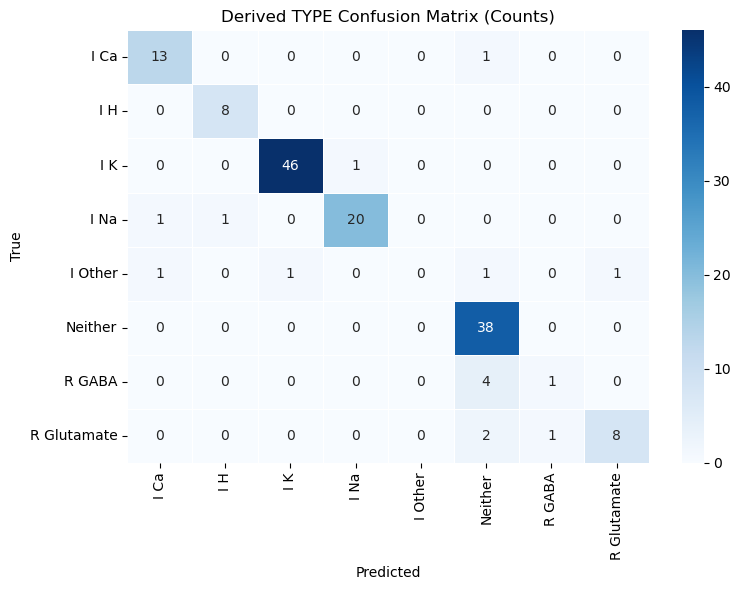

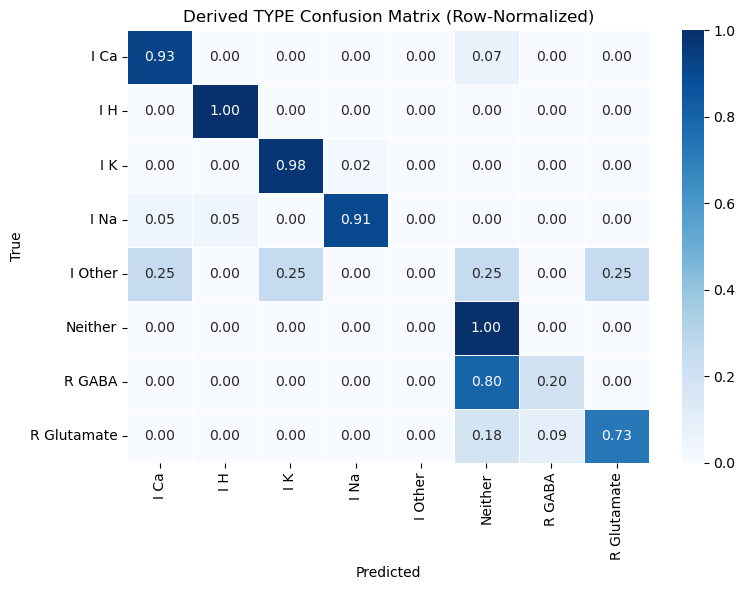

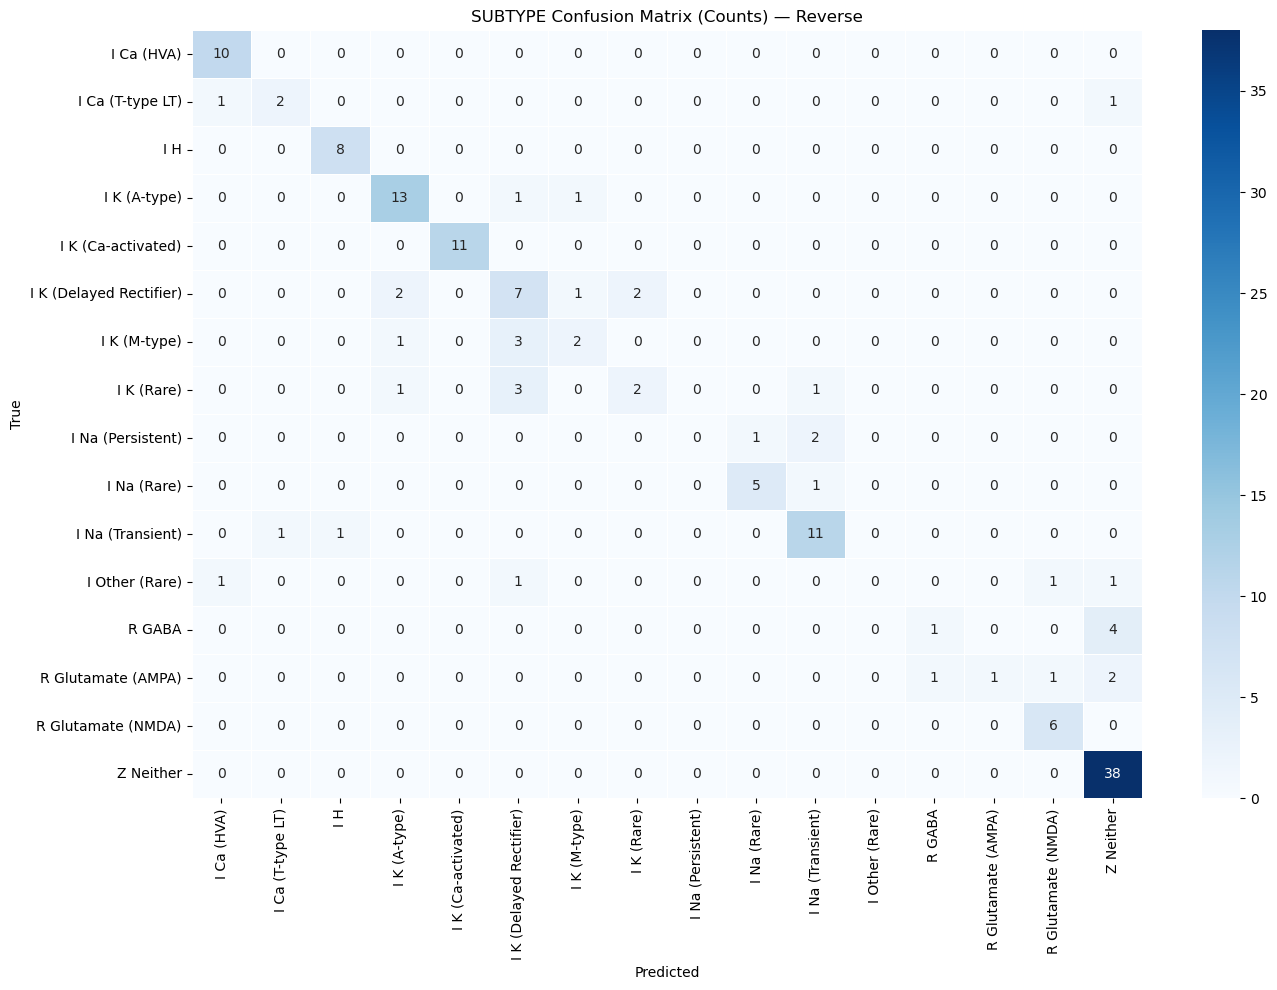

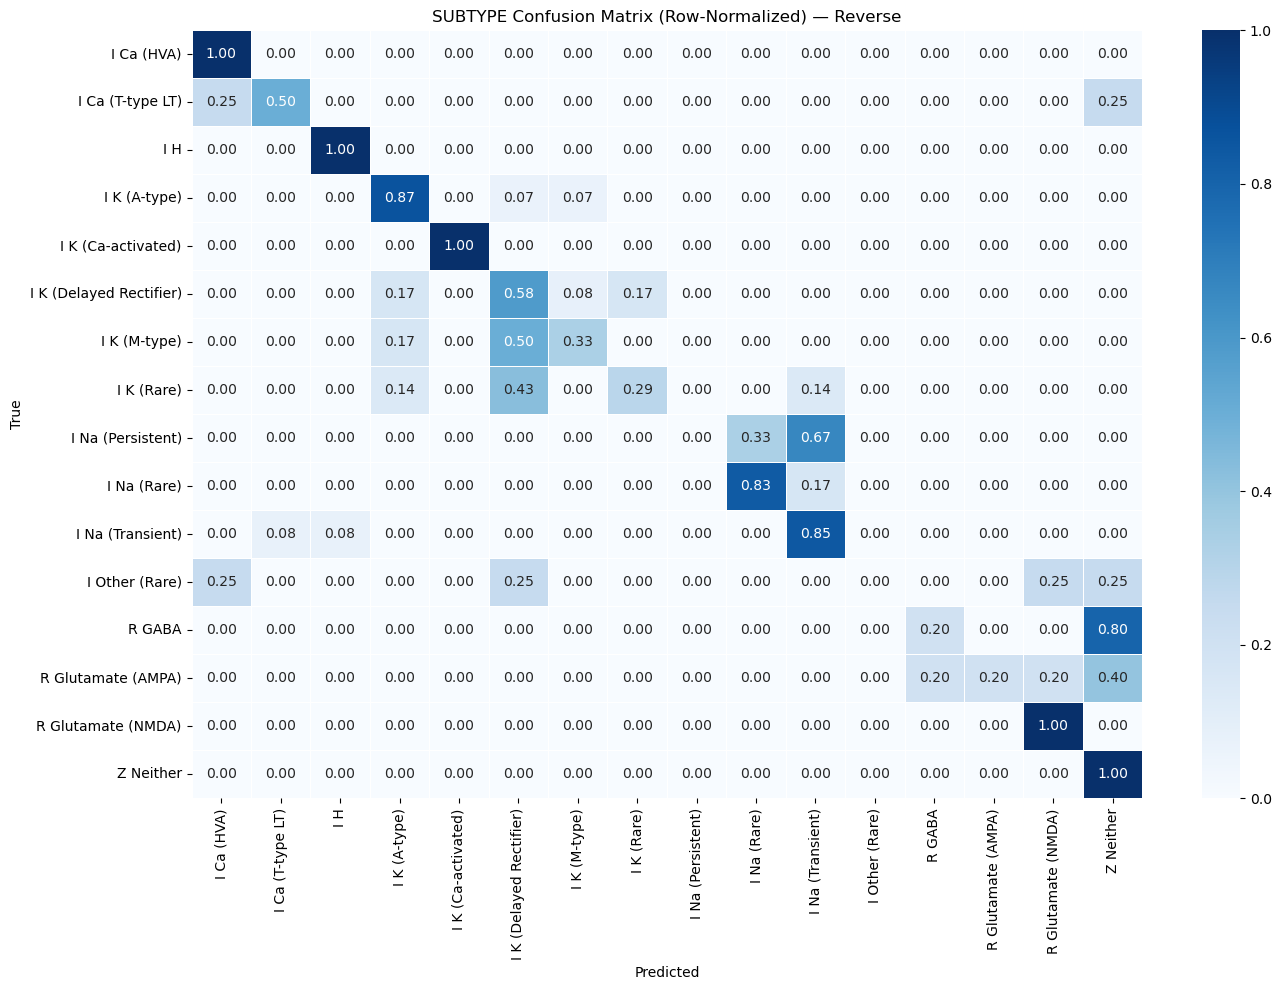

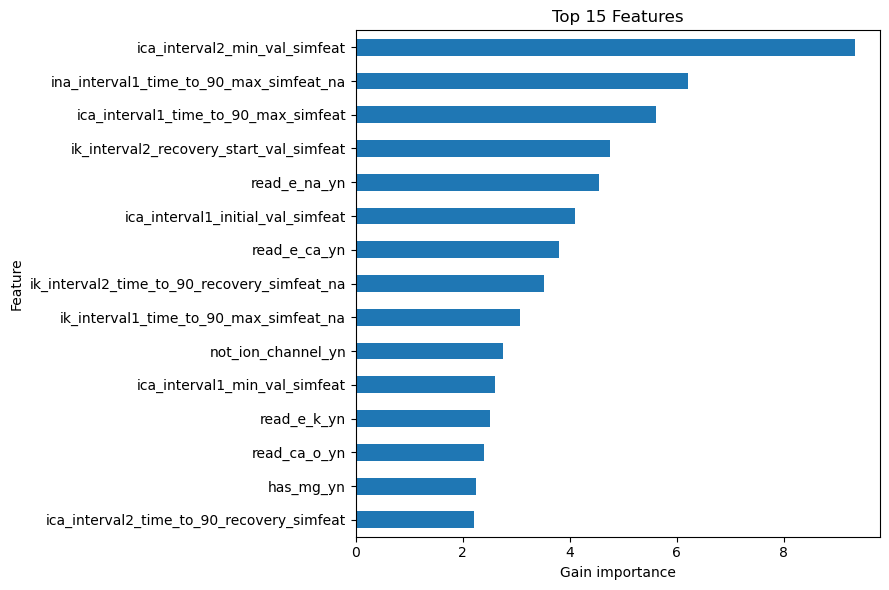

In [86]:
# --- CV splitter (yours) ---
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)

# --- Base estimator ---
base_xgb = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(subtype_encoder.classes_),
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=1,
    # optional: faster histogram algorithm if available
    tree_method="hist"
)

# --- Hyperparameter search space ---
# Keep ranges modest to balance exploration vs. runtime.
param_distributions = {
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.1, 0.2],
    "n_estimators": [200, 400, 800, 1200],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.5, 1.0],
    "reg_alpha": [0.0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0],
}

# --- RandomizedSearchCV (uses your cv) ---
from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=40,                 # increase/decrease as needed
    scoring="accuracy",
    cv=cv,
    random_state=SEED,
    n_jobs=1,                  # keep 1 if you need strict reproducibility
    refit=True,                # refit best params on full training set
    verbose=1
)

# --- Run search ---
search.fit(X_train_final, y_subtype_train_enc)
print(f"[Reverse] Best CV accuracy: {search.best_score_:.4f}")
print("[Reverse] Best params:", search.best_params_)

# Best tuned model already refit on full training data
subtype_model = search.best_estimator_

# --- Predict subtype ---
y_subtype_pred_enc_rev = subtype_model.predict(X_test_final)
y_subtype_pred_rev = subtype_encoder.inverse_transform(y_subtype_pred_enc_rev)

# --- Derive TYPE from predicted subtype using lookup ---
# Create a mapping from subtype to type using your ground truth
subtype_to_type_map = ant_df_long[['new_subtype_label', 'original_type_label']].drop_duplicates().set_index('new_subtype_label')['original_type_label'].to_dict()

# Map XGB's predicted subtypes to their correct types
y_type_pred_rev = pd.Series(y_subtype_pred_rev).map(subtype_to_type_map)

# --- Evaluation ---
print("\n=== Held-Out Evaluation (Reverse: subtype->type) ===")
print("Type Accuracy (derived from subtype):", accuracy_score(y_type_test, y_type_pred_rev))
print("\nSubtype Accuracy (overall):", accuracy_score(y_subtype_test, y_subtype_pred_enc_rev))
print("\nSubtype Classification Report (overall):")
print(classification_report(y_subtype_test, y_subtype_pred_rev))

# --- Confusion matrices ---
type_labels = sorted(pd.Series(y_type_test).unique())
plot_confusion(y_type_test, y_type_pred_rev, labels=type_labels,
               title="Derived TYPE Confusion Matrix (Counts)", figsize=(8, 6))
plot_confusion(y_type_test, y_type_pred_rev, labels=type_labels,
               title="Derived TYPE Confusion Matrix (Row-Normalized)", normalize="true", figsize=(8, 6))

subtype_labels = sorted(pd.Series(y_subtype_test).unique())
plot_confusion(y_subtype_test, y_subtype_pred_rev, labels=subtype_labels,
               title="SUBTYPE Confusion Matrix (Counts) — Reverse", figsize=(14, 10))
plot_confusion(y_subtype_test, y_subtype_pred_rev, labels=subtype_labels,
               title="SUBTYPE Confusion Matrix (Row-Normalized) — Reverse", normalize="true", figsize=(14, 10))

# --- Feature importance (reverse) ---
subtype_feat_imp_rev = xgb_gain_importance(subtype_model, X_train_final.columns)
plot_top_features(subtype_feat_imp_rev, "Top 15 Features")

In [87]:
booster = subtype_model.get_booster()

gain  = booster.get_score(importance_type="gain")
cover = booster.get_score(importance_type="cover")
weight = booster.get_score(importance_type="weight")

fi_csv = pd.DataFrame({
    "feature": list(gain.keys()),
    "gain": list(gain.values()),
    "cover": [cover.get(f, 0) for f in gain.keys()],
    "weight": [weight.get(f, 0) for f in gain.keys()]
})

fi_csv.to_csv("../data/pipeline/feature_importance_global.csv", index=False)

In [88]:
#fi_names = fi_csv[["feature"]]

In [89]:
#sheet = client.open("label_df")

# --- Select or create Sheet2 ---
#try:
#    worksheet = sheet.worksheet("Sheet2")  # If Sheet2 already exists
#except gspread.exceptions.WorksheetNotFound:
#    worksheet = sheet.add_worksheet(title="Sheet2", rows="1000", cols="20")


# --- Clear existing data & write new data ---
#worksheet.clear()
#worksheet.update([fi_names.columns.values.tolist()] + fi_names.values.tolist())

## SHAP Feature Importance

In [90]:
import numpy as np
import shap

# Build explainer (interventional is usually best for tree models)
explainer = shap.TreeExplainer(subtype_model, feature_perturbation="interventional")

# SHAP values for test set
shap_values = explainer.shap_values(X_test_final)  # list-of-arrays (classic) OR 3D array (newer SHAP)

# Predicted class positions per row (aligns with shap_values class order)
proba = subtype_model.predict_proba(X_test_final)          # shape (n_samples, n_classes)
pred_pos = np.asarray(proba).argmax(axis=1)                # shape (n_samples,)

n_samples, n_features = X_test_final.shape

# Get per-row SHAP for the predicted class, handling both SHAP formats
if isinstance(shap_values, list):
    # shap_values[k] -> (n_samples, n_features) for class k
    shap_pred = np.vstack([shap_values[k][i] for i, k in enumerate(pred_pos)])  # (n_samples, n_features)
else:
    # shap_values -> (n_samples, n_features, n_classes)
    shap_pred = shap_values[np.arange(n_samples), :, pred_pos]                  # (n_samples, n_features)

# Pack into a dataframe
df_shap = pd.DataFrame(shap_pred, columns=X_test_final.columns)
df_shap["hash"] = X_test_final.index


/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.


/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.


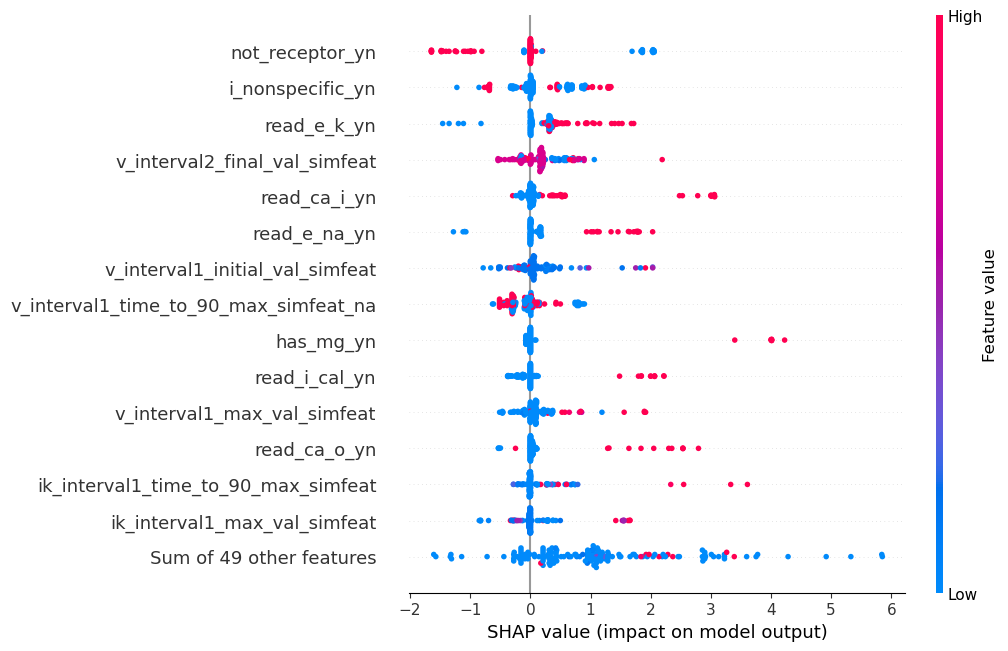

In [91]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# Compute SHAP values for all classes
explainer = shap.TreeExplainer(subtype_model, feature_perturbation="interventional")
shap_values_all = explainer(X_test_final)  # shap.Explanation, shape (n_samples, n_features, n_classes)

# Find predicted class index for each sample
proba = subtype_model.predict_proba(X_test_final)
pred_pos = np.argmax(proba, axis=1)

# Extract SHAP values for the predicted class per row
# (this converts from 3D → 2D)
shap_pred = np.array([shap_values_all.values[i, :, pred_pos[i]] for i in range(len(pred_pos))])

# Create new Explanation object for the selected SHAP values
shap_pred_expl = shap.Explanation(
    values=shap_pred,
    base_values=shap_values_all.base_values.mean(axis=1),  # average base_value across classes
    data=X_test_final,
    feature_names=X_test_final.columns
)

# --- Beeswarm plot ---
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_pred_expl, max_display=15)
plt.show()


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


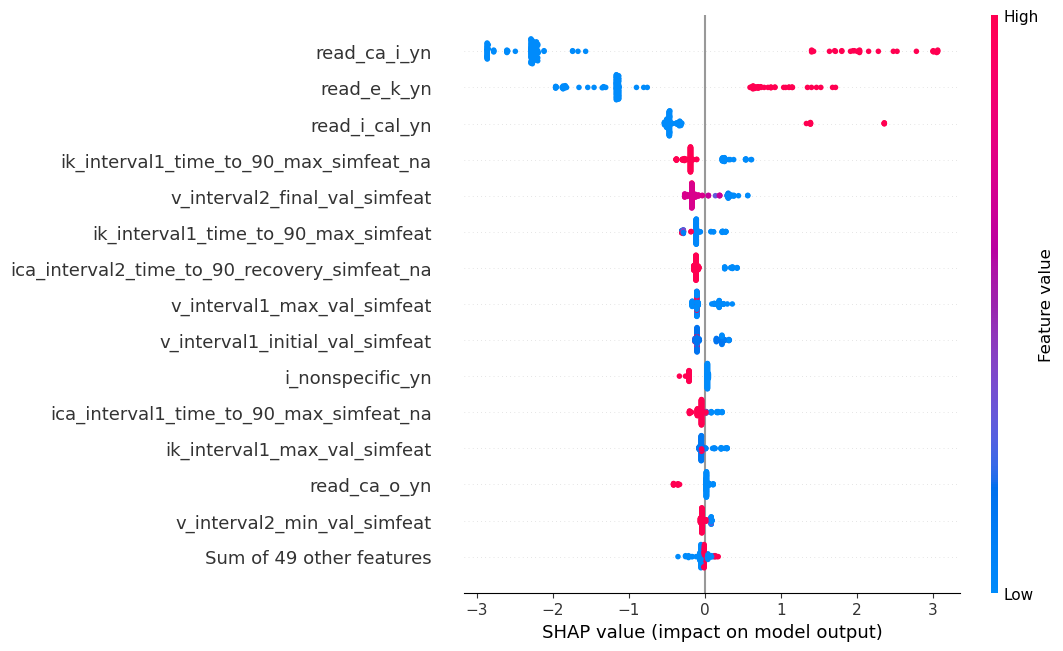

In [92]:
# shap_values_all: Explanation with shape (n_samples, n_features, n_classes)

# Print class order to confirm what "first" means
print(subtype_model.classes_)

# Select the first class (index 0)
class_idx = 4
shap_first = shap_values_all[..., class_idx]

# Beeswarm for that class
shap.plots.beeswarm(shap_first, max_display=15)



In [93]:
# Create an explainer
#explainer = shap.Explainer(subtype_model, X_test_final)
# Compute SHAP values
#shap_values = explainer(X_test_final)
#plt.title("I H")
#plt.title("I K A-type")
#plt.title("I KDR")
#shap.plots.beeswarm(shap_values[:,:,5])

## Combining XGB and GPT predictions together

In [94]:
# === Build DataFrame with predictions and truth ===

# True values from test set
true_subtype = y_subtype_test  # string labels
true_type = y_type_test        # string labels

# Build dataframe using reverse model predictions
df_xgb_pred = pd.DataFrame({
    "hash": X_test_selected.index,  # or X_test_final.index if X_test_selected isn't defined
    "true_type": true_type.values,
    "true_subtype": true_subtype.values,
    "xgb_pred_type": y_type_pred_rev.values,
    "xgb_pred_subtype": y_subtype_pred_rev
})

# Add match flags
df_xgb_pred["xgb_type_match"] = df_xgb_pred["true_type"] == df_xgb_pred["xgb_pred_type"]
df_xgb_pred["xgb_subtype_match"] = df_xgb_pred["true_subtype"] == df_xgb_pred["xgb_pred_subtype"]
df_both = df_xgb_pred.merge(gpt_df3, how="left", on="hash")
df_both["gpt_type_match"] = df_both["true_type"] == df_both["gpt_pred_type"]

df_both["gpt_subtype_match"] = df_both["true_subtype"] == df_both["gpt_pred_subtype"]


In [95]:
df_xgb_pred

,hash,true_type,true_subtype,xgb_pred_type,xgb_pred_subtype,xgb_type_match,xgb_subtype_match
0,73b297ba02582cdb6502679adf26acdc250524816c2488...,I K,I K (Delayed Rectifier),I K,I K (M-type),True,False
1,d70a9714d4593893267b7b54d6bb63ef2b0686599ee54b...,Neither,Z Neither,Neither,Z Neither,True,True
2,b8fabb50c57e580973c328e846f75b7e85724ca4503bb1...,I K,I K (Rare),I K,I K (Rare),False,True
3,8e102c7d99ef0627f3c70c2b4d5396a0db1098cb33312d...,R Glutamate,R Glutamate (NMDA),R Glutamate,R Glutamate (NMDA),True,True
4,840bc7359298d97bb410987ce6456f1666f232446f7552...,I K,I K (A-type),I K,I K (A-type),True,True
...,...,...,...,...,...,...,...
148,cbfac24751c2def2a3682683b8f956786e526e26052803...,R GABA,R GABA,R GABA,R GABA,True,True
149,1d8c7ec8140459eda79329406026daa5fea3364e1eff39...,I Na,I Na (Persistent),I Na,I Na (Rare),True,False
150,6c967beea674af628fb9505a42bb0ac77ba53a14dd2ad2...,I K,I K (Ca-activated),I K,I K (Ca-activated),True,True
151,a1577c9662b85b3948caac31cb378eddf944d1dc38106e...,I K,I K (Rare),I K,I K (Delayed Rectifier),True,False


In [96]:

# Optional: add confidence for convenience in R
max_prob = proba.max(axis=1)                       # model confidence of predicted class
df_conf = pd.DataFrame({"hash": X_test_final.index, "xgb_pred_prob": max_prob})

# Merge into df_both (which already has truth/preds/match flags)
df_both = df_both.merge(df_shap, on="hash", how="left").merge(df_conf, on="hash", how="left")

# Export for R
df_both.to_csv("../data/pipeline/predictions_with_shap.csv", index=False)


In [97]:
df_both

,hash,true_type,true_subtype,xgb_pred_type,xgb_pred_subtype,xgb_type_match,xgb_subtype_match,gpt_pred_type,gpt_pred_subtype,gpt_type_match,gpt_subtype_match,states_count,clamp_yn,suffix_yn,point_process_yn,net_receive_yn,i_nonspecific_yn,not_ion_channel_yn,not_receptor_yn,has_mg_yn,has_include_yn,has_include_cap_yn,read_ca_i_yn,read_ca_o_yn,read_e_ca_yn,read_e_k_yn,read_e_na_yn,read_e_other_yn,read_i_cal_yn,read_k_i_yn,read_k_o_yn,read_na_i_yn,write_ca_i_yn,write_i_cal_yn,write_i_k_yn,write_i_na_yn,write_i_other_yn,v_interval1_initial_val_simfeat,v_interval1_max_val_simfeat,v_interval2_time_to_90_recovery_simfeat,v_interval2_recovery_start_val_simfeat,v_interval2_final_val_simfeat,v_interval2_min_val_simfeat,ik_interval1_time_to_90_max_simfeat,ik_interval1_time_to_90_min_simfeat,ik_interval1_max_val_simfeat,ik_interval1_min_val_simfeat,ik_interval2_time_to_90_recovery_simfeat,ik_interval2_recovery_start_val_simfeat,ik_interval2_final_val_simfeat,ica_interval1_time_to_90_max_simfeat,ica_interval1_time_to_90_min_simfeat,ica_interval1_initial_val_simfeat,ica_interval1_max_val_simfeat,ica_interval1_min_val_simfeat,ica_interval2_time_to_90_recovery_simfeat,ica_interval2_final_val_simfeat,ica_interval2_max_val_simfeat,ica_interval2_min_val_simfeat,ina_interval1_time_to_90_max_simfeat,ina_interval1_time_to_90_min_simfeat,ina_interval1_initial_val_simfeat,ina_interval1_max_val_simfeat,ina_interval1_min_val_simfeat,ina_interval2_time_to_90_recovery_simfeat,ina_interval2_recovery_start_val_simfeat,ina_interval2_final_val_simfeat,v_interval1_time_to_90_max_simfeat_na,ik_interval1_time_to_90_max_simfeat_na,ik_interval2_time_to_90_recovery_simfeat_na,ica_interval1_time_to_90_max_simfeat_na,ica_interval2_time_to_90_recovery_simfeat_na,ina_interval1_time_to_90_max_simfeat_na,ina_interval2_time_to_90_recovery_simfeat_na,xgb_pred_prob
0,73b297ba02582cdb6502679adf26acdc250524816c2488...,I K,I K (Delayed Rectifier),I K,I K (M-type),True,False,I K,I K (Delayed Rectifier),True,True,-0.027587,0.000000,0.000000,0.000000,0.000000,0.006754,0.000000,0.000000,0.000000,0.000000,0.000000,0.030487,0.000000,0.000000,0.563664,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.555612,0.000000,0.000000,0.180048,-0.136868,0.085073,0.015029,0.408016,-0.043370,2.548169,0.235170,-0.000124,0.056918,-0.062112,0.228986,-0.383123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.287665,0.216008,0.143953,0.000000,0.000000,0.00000,0.000000,0.582055
1,d70a9714d4593893267b7b54d6bb63ef2b0686599ee54b...,Neither,Z Neither,Neither,Z Neither,True,True,Neither,Z Neither,True,True,0.009774,-0.012717,-0.155287,-0.140605,-0.012264,0.908115,0.571468,2.055604,-0.072039,-0.083750,0.073050,-0.011941,0.033942,0.037756,0.324465,0.164388,0.002646,-0.107587,0.000000,0.000000,-0.000652,-0.009124,0.066198,0.049702,0.007528,0.040047,0.053212,0.071381,0.000000,0.006009,0.160504,0.044531,-0.012146,0.000000,-0.009964,-0.009003,-0.001655,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-0.006582,-0.019008,0.000000,0.000000,0.000000,0.000000,0.000000,-0.306633,0.012480,-0.000880,-0.020152,-0.011990,0.00000,0.000000,0.987474
2,b8fabb50c57e580973c328e846f75b7e85724ca4503bb1...,I K,I K (Rare),I K,I K (Rare),False,True,Neither,Z Neither,False,False,0.118626,0.000000,0.000000,0.000000,0.000000,0.011651,0.000000,0.000000,0.000000,0.000000,0.000000,0.032169,0.000000,0.000000,0.428202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.515701,0.000000,0.000000,0.930595,0.329454,-0.171224,0.105394,-0.150693,0.026339,0.114695,-0.067066,0.213582,-0.615011,0.095987,0.112611,0.403507,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001113,0.000000,0.000000,-0.035195,0.126111,-0.036990,0.029148,0.000000,0.00000,0.000000,0.595708
3,8e102c7d99ef0627f3c70c2b4d5396a0db1098cb33312d...,R Glutamate,R Glutamate (NMDA),R Glutamate,R Glutamate (NMDA),True,True,R Gluta

In [98]:
#Checking Misclassfied XGB Samples
df_wrong = df_xgb_pred[
    (df_xgb_pred["xgb_type_match"] == False) |
    (df_xgb_pred["xgb_subtype_match"] == False)
]
MIS_TYPES = (
    df_wrong
    .query("xgb_type_match == False")["hash"]
    .tolist()
)
MIS_SUBTYPES = (
    df_wrong
    .query("xgb_subtype_match == False")["hash"]
    .tolist()
)

#df_wrong


# GPT performance

In [99]:
df_both.columns

Index(['hash', 'true_type', 'true_subtype', 'xgb_pred_type',
       'xgb_pred_subtype', 'xgb_type_match', 'xgb_subtype_match',
       'gpt_pred_type', 'gpt_pred_subtype', 'gpt_type_match',
       'gpt_subtype_match', 'states_count', 'clamp_yn', 'suffix_yn',
       'point_process_yn', 'net_receive_yn', 'i_nonspecific_yn',
       'not_ion_channel_yn', 'not_receptor_yn', 'has_mg_yn', 'has_include_yn',
       'has_include_cap_yn', 'read_ca_i_yn', 'read_ca_o_yn', 'read_e_ca_yn',
       'read_e_k_yn', 'read_e_na_yn', 'read_e_other_yn', 'read_i_cal_yn',
       'read_k_i_yn', 'read_k_o_yn', 'read_na_i_yn', 'write_ca_i_yn',
       'write_i_cal_yn', 'write_i_k_yn', 'write_i_na_yn', 'write_i_other_yn',
       'v_interval1_initial_val_simfeat', 'v_interval1_max_val_simfeat',
       'v_interval2_time_to_90_recovery_simfeat',
       'v_interval2_recovery_start_val_simfeat',
       'v_interval2_final_val_simfeat', 'v_interval2_min_val_simfeat',
       'ik_interval1_time_to_90_max_simfeat',
       'ik

In [100]:
#df_both[df_both["gpt_pred_subtype"].isna()]

GPT Type Accuracy: 0.7610

GPT Type Classification Report:
              precision    recall  f1-score   support

        I Ca       0.58      0.93      0.72        15
        I Cl       0.00      0.00      0.00         0
         I H       1.00      1.00      1.00         8
         I K       0.95      0.80      0.87        51
        I Na       0.85      0.77      0.81        22
     I Other       0.67      0.50      0.57         4
     Neither       0.61      0.58      0.60        43
      R GABA       1.00      0.60      0.75         5
 R Glutamate       0.69      1.00      0.81        11

    accuracy                           0.76       159
   macro avg       0.71      0.69      0.68       159
weighted avg       0.79      0.76      0.77       159



/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


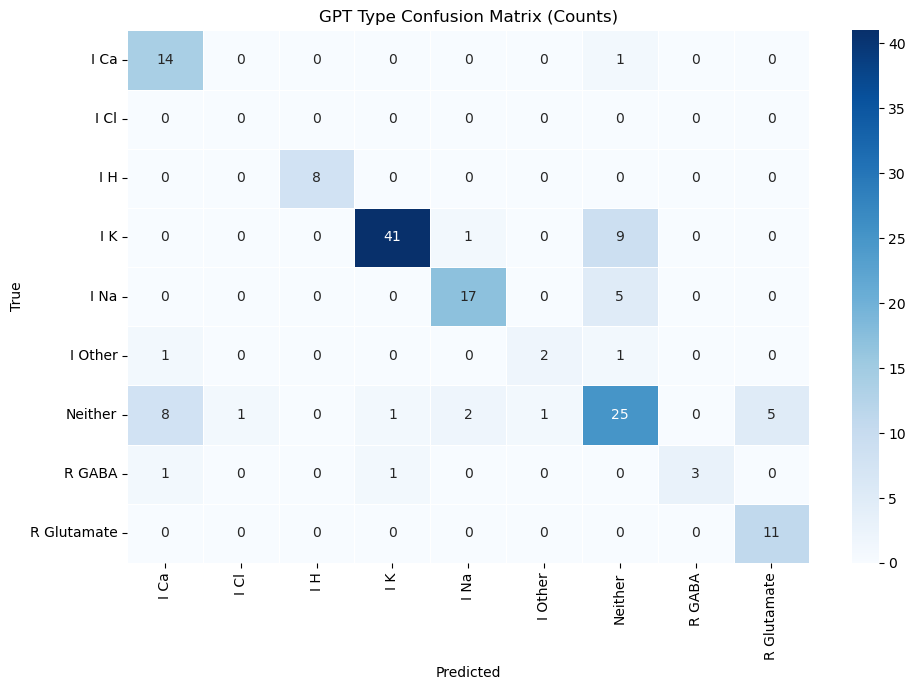

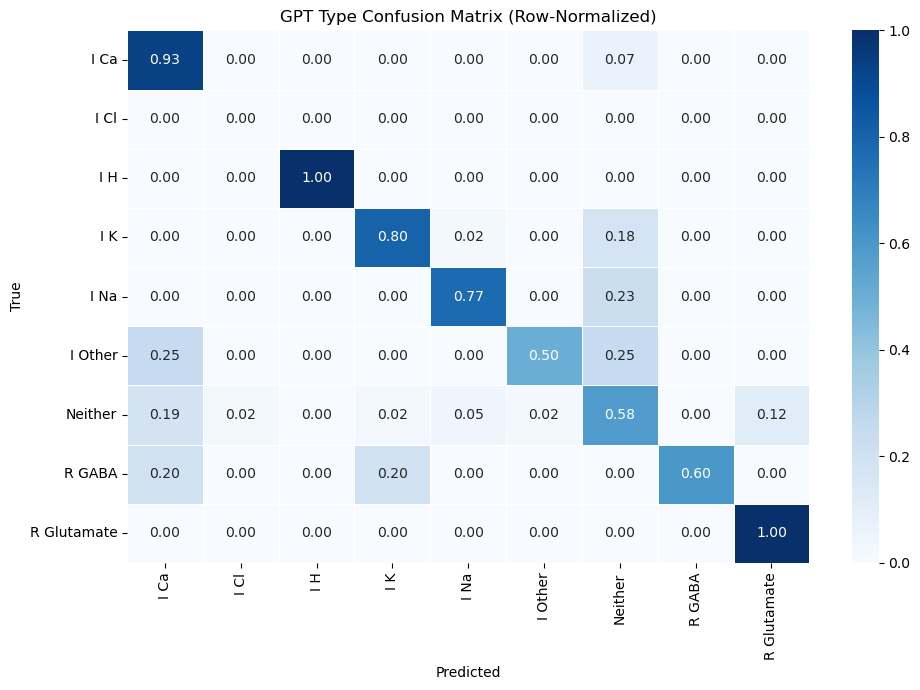


GPT Subtype Accuracy (Overall): 0.7233

GPT Subtype Classification Report (Overall):
                         precision    recall  f1-score   support

             I Ca (HVA)       0.90      0.82      0.86        11
            I Ca (Rare)       0.00      0.00      0.00         0
       I Ca (T-type LT)       0.80      1.00      0.89         4
                  I Cl        0.00      0.00      0.00         0
                    I H       1.00      1.00      1.00         8
           I K (A-type)       0.93      0.93      0.93        15
     I K (Ca-activated)       1.00      0.64      0.78        11
I K (Delayed Rectifier)       1.00      0.67      0.80        12
           I K (M-type)       1.00      1.00      1.00         6
             I K (Rare)       0.57      0.57      0.57         7
      I Na (Persistent)       1.00      0.67      0.80         3
            I Na (Rare)       0.25      0.17      0.20         6
       I Na (Transient)       0.79      0.85      0.81        13
   

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


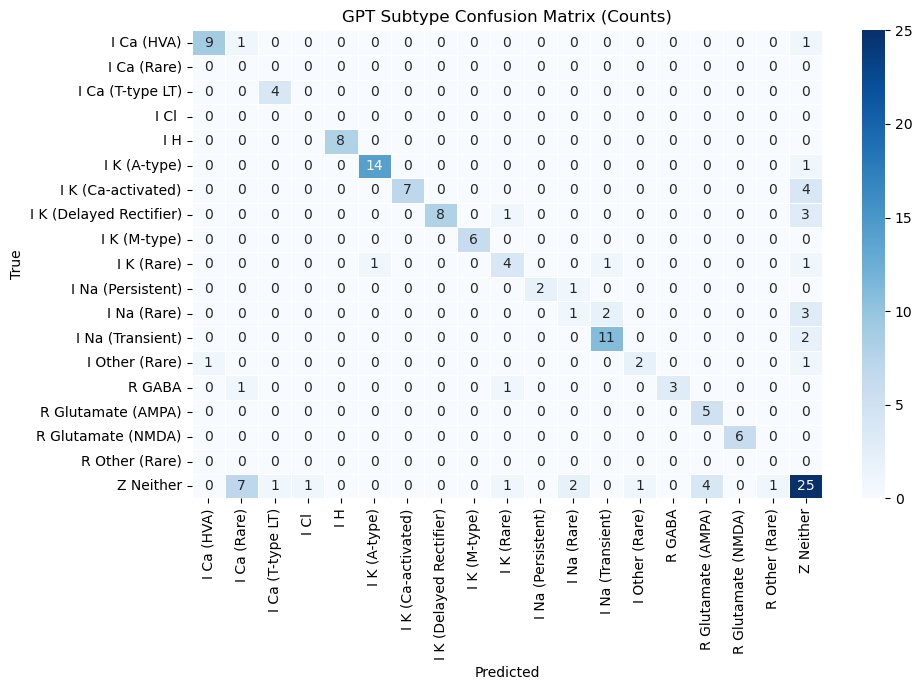

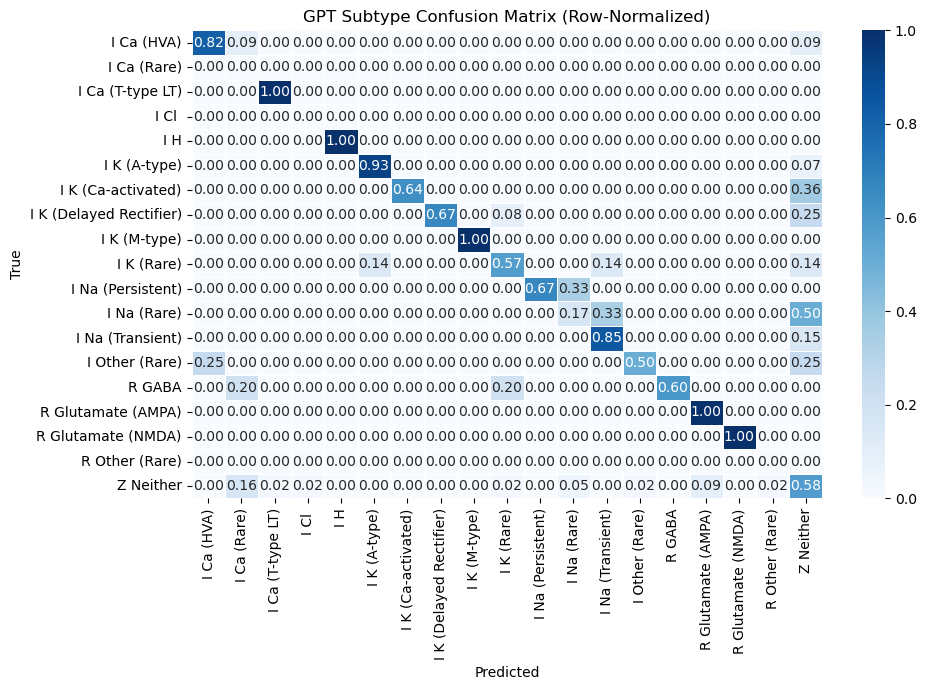

In [101]:
# --- helper: reusable confusion matrix plotter ---
def plot_confusion(y_true, y_pred, title, normalize=None, figsize=(10, 7)):
    # Collect labels present in either true or predicted
    labels = sorted(pd.unique(pd.concat([pd.Series(y_true), pd.Series(y_pred)])))
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=figsize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm_df, annot=True, fmt=fmt, cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# === Overall GPT Type Accuracy ===
gpt_type_acc = accuracy_score(df_both["true_type"], df_both["gpt_pred_type"])
print(f"GPT Type Accuracy: {gpt_type_acc:.4f}")

print("\nGPT Type Classification Report:")
print(classification_report(
    df_both["true_type"],
    df_both["gpt_pred_type"]
))

# --- Type confusion matrices (counts + row-normalized) ---
plot_confusion(
    df_both["true_type"],
    df_both["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    df_both["true_type"],
    df_both["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Row-Normalized)",
    normalize="true"
)

# === Overall GPT Subtype Accuracy (no conditioning) ===
gpt_subtype_acc = accuracy_score(
    df_both["true_subtype"], df_both["gpt_pred_subtype"]
)
print(f"\nGPT Subtype Accuracy (Overall): {gpt_subtype_acc:.4f}")

print("\nGPT Subtype Classification Report (Overall):")
print(classification_report(
    df_both["true_subtype"],
    df_both["gpt_pred_subtype"]
))

# --- Subtype confusion matrices (overall) ---
plot_confusion(
    df_both["true_subtype"],
    df_both["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    df_both["true_subtype"],
    df_both["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Row-Normalized)",
    normalize="true"
)


# Merging them

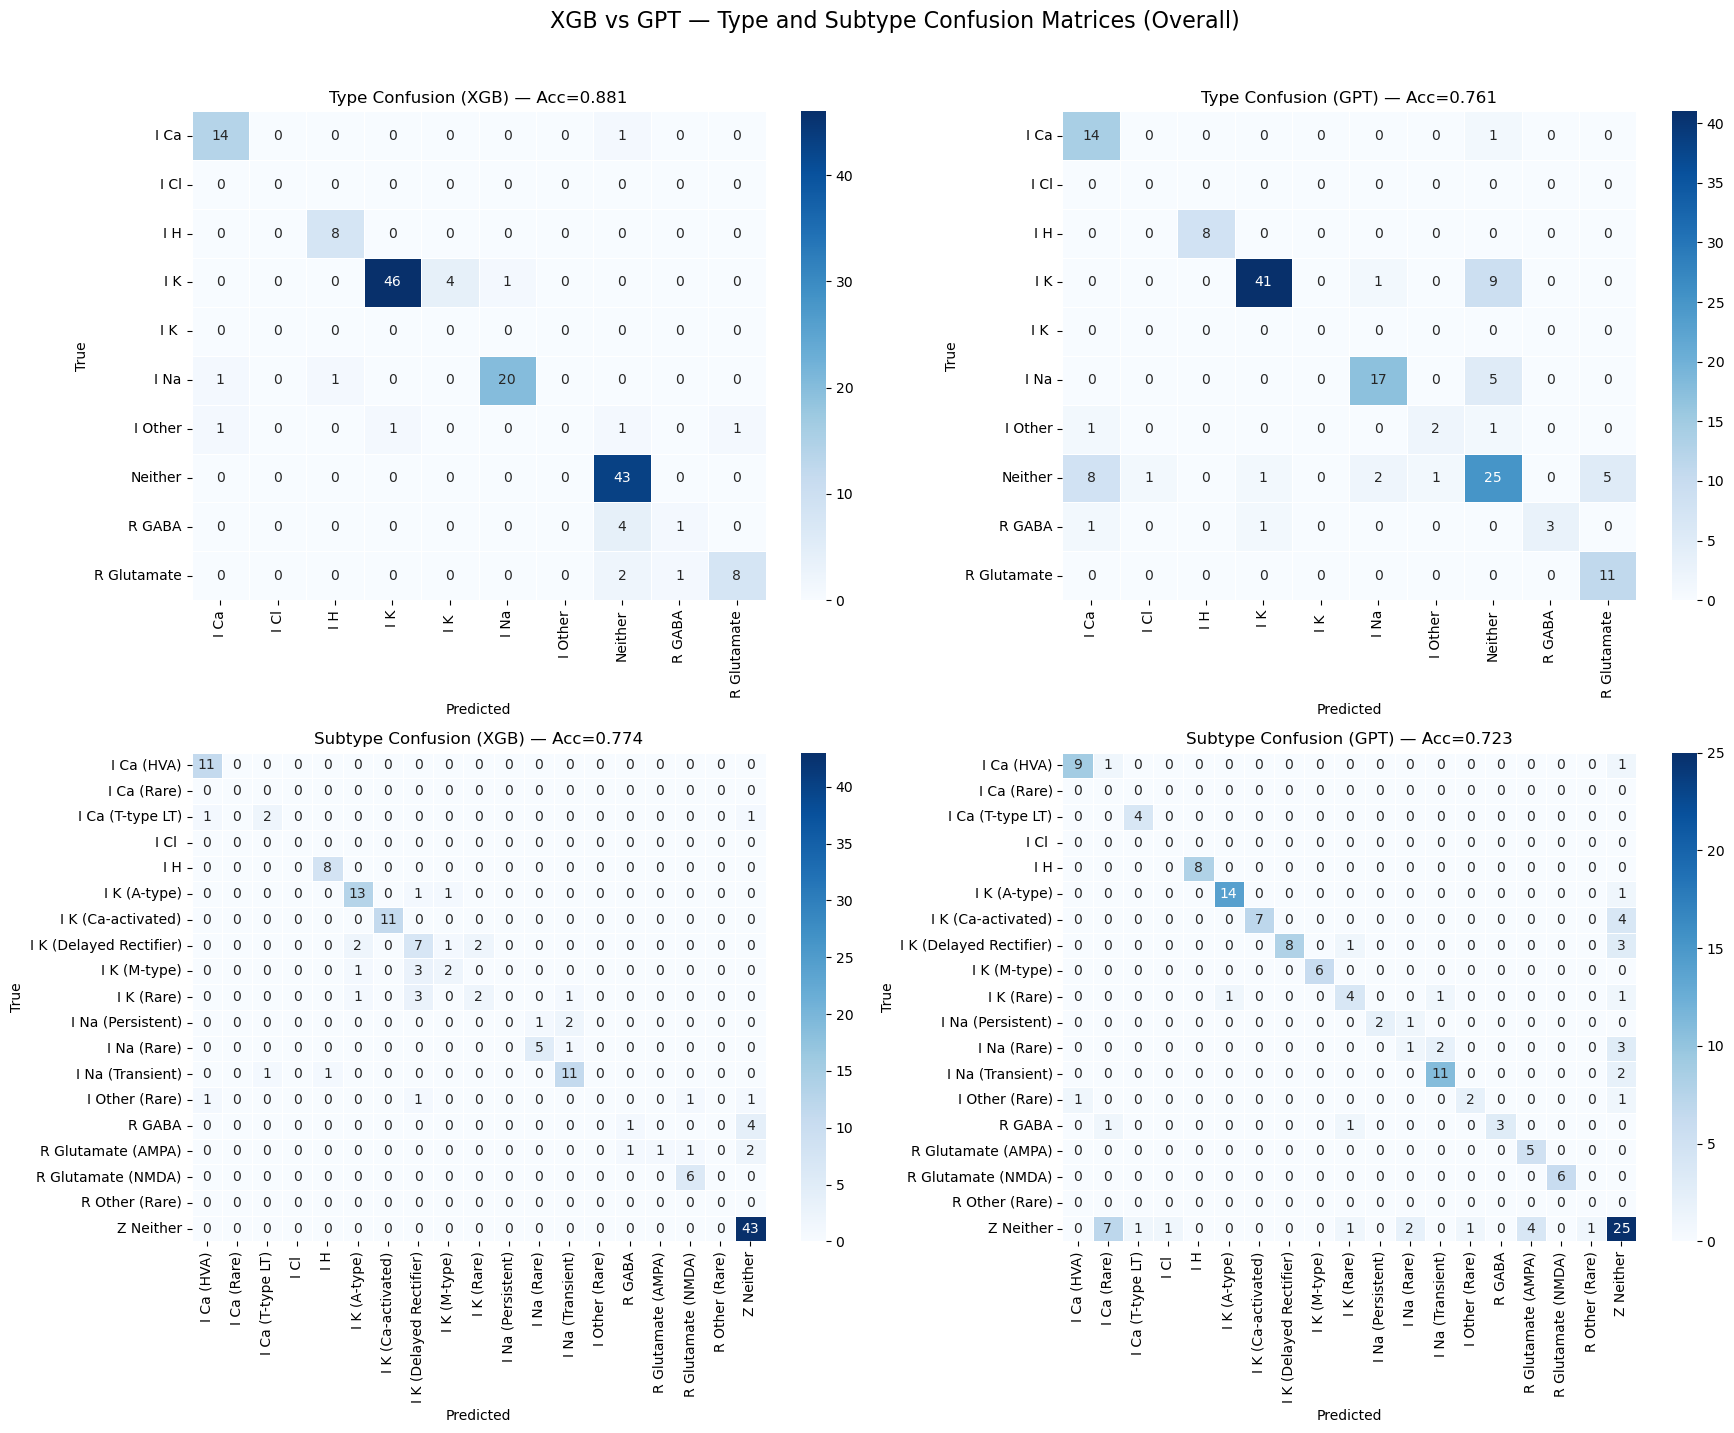

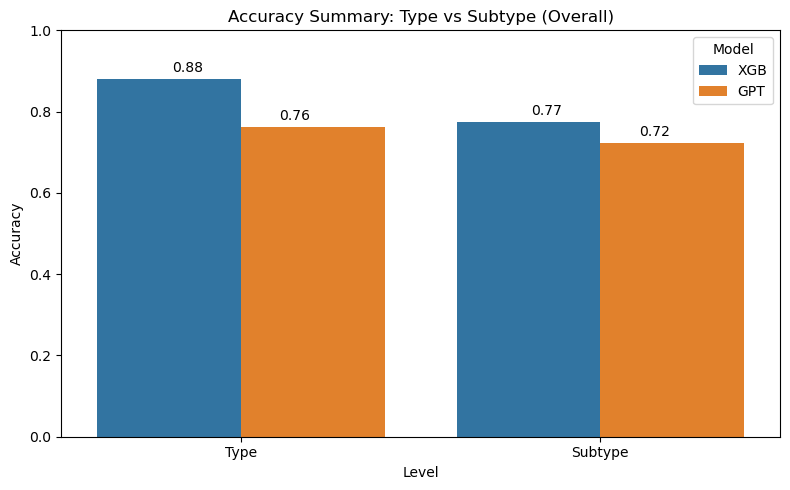

In [102]:
# ====== helpers ======
def _labels_from(*series_list):
    s = pd.concat([pd.Series(s) for s in series_list], ignore_index=True)
    return sorted(s.dropna().unique().tolist())

def plot_cm(ax, y_true, y_pred, labels, title, normalize=None, annot=True):
    if len(y_true) == 0:
        ax.axis('off')
        ax.text(0.5, 0.5, "No samples", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        return
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm, ax=ax, annot=annot, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=90)

# ====== assemble labels ======
type_labels = _labels_from(
    df_both["true_type"], 
    df_both["gpt_pred_type"], 
    df_both["xgb_pred_type"]
)
subtype_labels = _labels_from(
    df_both["true_subtype"], 
    df_both["gpt_pred_subtype"], 
    df_both["xgb_pred_subtype"]
)

# ====== accuracies ======
acc_type_gpt = accuracy_score(df_both["true_type"], df_both["gpt_pred_type"])
acc_type_xgb = accuracy_score(df_both["true_type"], df_both["xgb_pred_type"])

acc_sub_gpt = accuracy_score(df_both["true_subtype"], df_both["gpt_pred_subtype"])
acc_sub_xgb = accuracy_score(df_both["true_subtype"], df_both["xgb_pred_subtype"])

# ====== 2x2 confusion matrices: Type (XGB/GPT) + Subtype (XGB/GPT) ======
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Type — XGB left, GPT right
plot_cm(
    axes[0, 0],
    df_both["true_type"], df_both["xgb_pred_type"], type_labels,
    title=f"Type Confusion (XGB) — Acc={acc_type_xgb:.3f}"
)
plot_cm(
    axes[0, 1],
    df_both["true_type"], df_both["gpt_pred_type"], type_labels,
    title=f"Type Confusion (GPT) — Acc={acc_type_gpt:.3f}"
)

# Subtype — XGB left, GPT right (no conditioning)
plot_cm(
    axes[1, 0],
    df_both["true_subtype"], df_both["xgb_pred_subtype"], subtype_labels,
    title=f"Subtype Confusion (XGB) — Acc={acc_sub_xgb:.3f}"
)
plot_cm(
    axes[1, 1],
    df_both["true_subtype"], df_both["gpt_pred_subtype"], subtype_labels,
    title=f"Subtype Confusion (GPT) — Acc={acc_sub_gpt:.3f}"
)

fig.suptitle("XGB vs GPT — Type and Subtype Confusion Matrices (Overall)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ====== Summary accuracy bar chart ======
acc_df = pd.DataFrame({
    "Model": ["XGB", "GPT", "XGB", "GPT"],
    "Level": ["Type", "Type", "Subtype", "Subtype"],
    "Accuracy": [acc_type_xgb, acc_type_gpt, acc_sub_xgb, acc_sub_gpt]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=acc_df, x="Level", y="Accuracy", hue="Model", hue_order=["XGB", "GPT"])
plt.ylim(0, 1)
plt.title("Accuracy Summary: Type vs Subtype (Overall)")
for i, v in enumerate(acc_df["Accuracy"]):
    plt.text(x=i//2 + (-0.15 if i % 2 == 0 else 0.15),
             y=min(0.98, (0 if np.isnan(v) else v)) + 0.01,
             s=("NA" if np.isnan(v) else f"{v:.2f}"),
             ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


In [103]:
#76.9,74.4